# Mapper v3.2: OPRA Pretraining and Architecture Experiments

Новый ноутбук для EarLoop / Mapper v3. Старые ноутбуки считаются зафиксированными экспериментами и не изменяются.

Задача этого ноутбука:

- воспроизвести текущий baseline `weighted 8D v3.1b + lambda_ctrl=0.003`;
- проверить `OPRA -> SocialFX` pretrain/fine-tune;
- проверить `BasisResidualMapper`;
- сравнить reconstruction quality и controllability только на общем SocialFX split.

Зафиксированные предыдущие результаты:

1. `old 6D baseline`: test MSE ≈ 0.04398, mean basis alignment ≈ 0.205
2. `weighted 8D v3.0`: test MSE ≈ 0.03408, mean basis alignment ≈ 0.626
3. `weighted 8D v3.1 ctrl=0.01`: alignment выше, leakage ниже, но brightness почти подавлен
4. `weighted 8D v3.1b ctrl=0.003`: текущий лучший компромисс, test MSE ≈ 0.03398, mean basis alignment ≈ 0.695, mean target/off ratio ≈ 3.71, mean sign consistency ≈ 0.928


In [1]:
# ==== Imports and config ====

from pathlib import Path
import json
import random
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from matplotlib.ticker import NullFormatter
from IPython.display import Markdown, display


SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)


OUTPUT_DIR = Path("outputs")
MODEL_DIR = OUTPUT_DIR / "models"
METRICS_DIR = OUTPUT_DIR / "metrics"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

SOCIALFX_8D_PATH = OUTPUT_DIR / "socialfx_curves_with_8d.parquet"
OPRA_8D_PATH = OUTPUT_DIR / "opra_eq_profiles_with_8d.parquet"

print("SocialFX 8D file:", SOCIALFX_8D_PATH.resolve())
print("OPRA 8D file:", OPRA_8D_PATH.resolve())


Device: cpu
SocialFX 8D file: C:\Users\makcc\PycharmProjects\EarLoop\research\mapper_v2\outputs\socialfx_curves_with_8d.parquet
OPRA 8D file: C:\Users\makcc\PycharmProjects\EarLoop\research\mapper_v2\outputs\opra_eq_profiles_with_8d.parquet


In [2]:
# ==== Helpers ====

FEATURE_NAMES_8D = [
    "sub_bass",
    "bass",
    "lowmid",
    "warmth",
    "presence",
    "clarity",
    "air",
    "brightness",
]


def reset_seeds(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def parse_array_value(value, dtype=np.float32):
    if isinstance(value, np.ndarray):
        return value.astype(dtype)

    if isinstance(value, list):
        return np.asarray(value, dtype=dtype)

    if isinstance(value, str):
        return np.asarray(json.loads(value), dtype=dtype)

    raise TypeError(f"Unsupported array value type: {type(value)}")


def format_freq_label(f):
    if f >= 1000:
        value = f / 1000
        if abs(value - round(value)) < 1e-6:
            return f"{int(round(value))} kHz"
        return f"{value:g} kHz"

    if abs(f - round(f)) < 1e-6:
        return f"{int(round(f))} Hz"

    return f"{f:g} Hz"


def style_freq_axis(
    ax,
    freqs,
    xlabel="Frequency (Hz)",
    ylabel="Gain (dB)",
    title=None,
    ylim=None,
    legend=True,
    legend_ncol=2,
):
    freqs = np.asarray(freqs, dtype=float)

    ax.set_xscale("log")
    ax.set_xlabel(xlabel)

    if ylabel is not None:
        ax.set_ylabel(ylabel)

    if title is not None:
        ax.set_title(title)

    ax.grid(True, which="major", alpha=0.35)
    ax.grid(True, which="minor", alpha=0.12)

    nice_ticks = np.array(
        [20, 50, 83, 120, 200, 383, 622, 1000, 1500, 2400, 4400, 6900, 12000, 16000],
        dtype=float,
    )
    nice_ticks = nice_ticks[(nice_ticks >= freqs.min()) & (nice_ticks <= freqs.max())]

    ax.set_xticks(nice_ticks)
    ax.set_xticklabels([format_freq_label(f) for f in nice_ticks])
    ax.xaxis.set_minor_formatter(NullFormatter())

    if ylim is not None:
        ax.set_ylim(*ylim)

    if legend:
        ax.legend(loc="best", ncol=legend_ncol)

    plt.tight_layout()


In [3]:
# ==== Load SocialFX and OPRA 8D datasets ====

def load_8d_dataset(path, dataset_name, default_freqs=None):
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")

    df = pd.read_parquet(path).copy()

    if "curve_23_json" in df.columns:
        df["curve_23"] = df["curve_23_json"].apply(parse_array_value)
    elif "curve_23" in df.columns:
        df["curve_23"] = df["curve_23"].apply(parse_array_value)
    else:
        raise ValueError(f"{dataset_name} file must contain curve_23_json or curve_23.")

    if "z8_norm_json" in df.columns:
        df["z8_norm"] = df["z8_norm_json"].apply(parse_array_value)
    elif "z8_norm" in df.columns:
        df["z8_norm"] = df["z8_norm"].apply(parse_array_value)
    else:
        norm_cols = [f"z8n_{name}" for name in FEATURE_NAMES_8D]
        if all(c in df.columns for c in norm_cols):
            df["z8_norm"] = list(df[norm_cols].to_numpy(dtype=np.float32))
        else:
            raise ValueError(
                f"{dataset_name} file must contain z8_norm_json, z8_norm, or z8n_* columns."
            )

    if "freqs_23_json" in df.columns:
        df["freqs_23"] = df["freqs_23_json"].apply(lambda x: parse_array_value(x, dtype=float))
    elif "freqs_23" in df.columns:
        df["freqs_23"] = df["freqs_23"].apply(lambda x: parse_array_value(x, dtype=float))
    elif default_freqs is not None:
        df["freqs_23"] = [np.asarray(default_freqs, dtype=float) for _ in range(len(df))]
    else:
        raise ValueError(f"{dataset_name} file must contain freqs_23_json or freqs_23.")

    return df


df_socialfx = load_8d_dataset(SOCIALFX_8D_PATH, "SocialFX")
freqs_23 = np.asarray(df_socialfx.iloc[0]["freqs_23"], dtype=float)
df_opra = load_8d_dataset(OPRA_8D_PATH, "OPRA", default_freqs=freqs_23)

X_social = np.stack(df_socialfx["z8_norm"].values).astype(np.float32)
Y_social = np.stack(df_socialfx["curve_23"].values).astype(np.float32)

X_opra = np.stack(df_opra["z8_norm"].values).astype(np.float32)
Y_opra = np.stack(df_opra["curve_23"].values).astype(np.float32)

print("SocialFX:", df_socialfx.shape, X_social.shape, Y_social.shape)
print("OPRA:", df_opra.shape, X_opra.shape, Y_opra.shape)
print("freqs_23:", freqs_23)
display(df_socialfx.head(2))
display(df_opra.head(2))


SocialFX: (1595, 56) (1595, 8) (1595, 23)
OPRA: (12593, 57) (12593, 8) (12593, 23)
freqs_23: [   20.            50.            83.           120.
   159.51029968   200.04376221   254.04821777   308.56271362
   383.           443.86398315   622.04351807   798.06713867
  1000.          1485.98254395  1875.          2368.08081055
  3389.64819336  4365.36328125  6934.26074219  8568.99511719
 12000.         14000.         16000.        ]


,id,text,lang,ratings_consistency,curve_40,freqs_40,n_bands_40,n_bands_23,bass_40_raw,bass_23_raw,...,z8n_clarity,z8n_air,z8n_brightness,curve_23_json,freqs_23_json,z8_raw_json,z8_norm_json,curve_23,z8_norm,freqs_23
0,eq_0,hot,English,0.797209,"[-1.2872984409332275, -1.5329641103744507, -1....","[20.0, 50.0, 83.0, 120.0, 161.0, 208.0, 259.0,...",40,23,-1.287566,-1.290872,...,-0.343426,-0.706571,0.293874,"[-1.2872984409332275, -1.5329641103744507, -1....","[20.0, 50.0, 83.0, 120.0, 159.5102996826172, 2...","[-1.465518593788147, -1.1774649620056152, 0.27...","[-1.2100446224212646, -1.0599281787872314, 0.1...","[-1.2872984, -1.5329641, -1.5065393, -1.396974...","[-1.2100446, -1.0599282, 0.14392601, 1.7138251...","[20.0, 50.0, 83.0, 120.0, 159.5102996826172, 2..."
1,eq_1,wet,English,0.481343,"[-0.9765962958335876, -0.7818208336830139, -0....","[20.0, 50.0, 83.0, 120.0, 161.0, 208.0, 259.0,...",40,23,-0.725170,-0.726108,...,1.116719,2.355583,1.531152,"[-0.9765962958335876, -0.7818208336830139, -0....","[20.0, 50.0, 83.0, 120.0, 159.5102996826172, 2...","[-0.7437889575958252, -0.7635607123374939, -0....","[-0.6681138873100281, -0.7345297336578369, -1....","[-0.9765963, -0.78182083, -0.56064045, -0.6097...","[-0.6681139, -0.73452973, -1.1000185, -1.17484...","[20.0, 50.0, 83.0, 120.0, 159.5102996826172, 2..."


,source_dataset,relative_path,filename,suffix,profile_type,num_points,num_filters,gain_min,gain_max,gain_abs_max,...,z8n_warmth,z8n_presence,z8n_clarity,z8n_air,z8n_brightness,z8_raw_json,z8_norm_json,curve_23,z8_norm,freqs_23
0,opra,database\vendors\1custom\products\sa02\eq\auto...,info.json,.json,json_parametric,0,10,-1.055203,5.488164,5.488164,...,0.002331,-0.001788,-0.326772,-0.809600,-1.565261,"[4.495275974273682, 1.824123740196228, 0.20799...","[3.2657837867736816, 1.29982590675354, 0.07500...","[5.4881635, 5.1938915, 3.9035857, 2.0669541, 0...","[3.2657838, 1.2998259, 0.07500542, 0.002331110...","[20.0, 50.0, 83.0, 120.0, 159.5102996826172, 2..."
1,opra,database\vendors\1custom\products\sa03\eq\auto...,info.json,.json,json_parametric,0,10,-1.822291,2.395032,2.395032,...,-0.024500,-0.029413,-0.612454,-1.517421,-1.053189,"[1.965944528579712, 0.7925931215286255, 0.0882...","[1.3665648698806763, 0.4888691306114197, -0.05...","[2.3950322, 2.271908, 1.7140299, 0.8947236, 0....","[1.3665649, 0.48886913, -0.055846192, -0.02450...","[20.0, 50.0, 83.0, 120.0, 159.5102996826172, 2..."


In [4]:
# ==== Shared SocialFX split and OPRA pretrain split ====

indices_social = np.arange(len(df_socialfx))

idx_train, idx_temp = train_test_split(
    indices_social,
    test_size=0.2,
    random_state=SEED,
)

idx_val, idx_test = train_test_split(
    idx_temp,
    test_size=0.5,
    random_state=SEED,
)


def split_by_indices(X, Y, train_idx, val_idx, test_idx):
    return (
        X[train_idx],
        Y[train_idx],
        X[val_idx],
        Y[val_idx],
        X[test_idx],
        Y[test_idx],
    )


X_train, Y_train, X_val, Y_val, X_test, Y_test = split_by_indices(
    X_social,
    Y_social,
    idx_train,
    idx_val,
    idx_test,
)

indices_opra = np.arange(len(df_opra))
idx_opra_train, idx_opra_val = train_test_split(
    indices_opra,
    test_size=0.1,
    random_state=SEED,
)

X_opra_train = X_opra[idx_opra_train]
Y_opra_train = Y_opra[idx_opra_train]
X_opra_val = X_opra[idx_opra_val]
Y_opra_val = Y_opra[idx_opra_val]

print("SocialFX train:", X_train.shape, Y_train.shape)
print("SocialFX val:  ", X_val.shape, Y_val.shape)
print("SocialFX test: ", X_test.shape, Y_test.shape)
print("OPRA train:", X_opra_train.shape, Y_opra_train.shape)
print("OPRA val:  ", X_opra_val.shape, Y_opra_val.shape)


SocialFX train: (1276, 8) (1276, 23)
SocialFX val:   (159, 8) (159, 23)
SocialFX test:  (160, 8) (160, 23)
OPRA train: (11333, 8) (11333, 23)
OPRA val:   (1260, 8) (1260, 23)


In [5]:
# ==== Dataset and core models ====

class EqDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]


class MapperMLP(nn.Module):
    def __init__(
        self,
        input_dim,
        output_dim,
        hidden_dims=(128, 128, 64),
        activation="gelu",
        dropout=0.0,
    ):
        super().__init__()

        if activation == "relu":
            act_layer = nn.ReLU
        elif activation == "gelu":
            act_layer = nn.GELU
        elif activation == "leaky_relu":
            act_layer = nn.LeakyReLU
        else:
            raise ValueError(f"Unsupported activation: {activation}")

        layers = []
        prev_dim = input_dim

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(act_layer())

            if dropout > 0:
                layers.append(nn.Dropout(dropout))

            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, output_dim))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


In [6]:
# ==== Mapper experiment ====

class MapperExperiment:
    def __init__(
        self,
        model,
        X_train,
        Y_train,
        X_val,
        Y_val,
        X_test,
        Y_test,
        freqs,
        batch_size=64,
        lr=1e-3,
        weight_decay=1e-5,
        lambda_smooth=0.0,
        device=None,
    ):
        self.model = model
        self.freqs = np.asarray(freqs, dtype=float)

        self.X_train = X_train
        self.Y_train = Y_train
        self.X_val = X_val
        self.Y_val = Y_val
        self.X_test = X_test
        self.Y_test = Y_test

        self.batch_size = batch_size
        self.lr = lr
        self.weight_decay = weight_decay
        self.lambda_smooth = lambda_smooth

        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.model.to(self.device)

        self.history = []

        self.train_loader = self._make_loader(X_train, Y_train, shuffle=True)
        self.val_loader = self._make_loader(X_val, Y_val, shuffle=False)
        self.test_loader = self._make_loader(X_test, Y_test, shuffle=False)

    def _make_loader(self, X, Y, shuffle):
        dataset = EqDataset(X, Y)

        return DataLoader(
            dataset,
            batch_size=self.batch_size,
            shuffle=shuffle,
        )

    def smoothness_penalty(self, y_pred):
        diff = y_pred[:, 1:] - y_pred[:, :-1]
        return torch.mean(diff ** 2)

    def _run_epoch(self, loader, optimizer=None):
        is_train = optimizer is not None
        self.model.train(is_train)

        total_loss_sum = 0.0
        total_mse_sum = 0.0
        total_smooth_sum = 0.0
        total_count = 0

        for xb, yb in loader:
            xb = xb.to(self.device)
            yb = yb.to(self.device)

            y_pred = self.model(xb)

            mse = torch.mean((y_pred - yb) ** 2)
            smooth = self.smoothness_penalty(y_pred)
            loss = mse + self.lambda_smooth * smooth

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            batch_size = xb.size(0)

            total_loss_sum += loss.item() * batch_size
            total_mse_sum += mse.item() * batch_size
            total_smooth_sum += smooth.item() * batch_size
            total_count += batch_size

        return {
            "loss": total_loss_sum / total_count,
            "mse": total_mse_sum / total_count,
            "smooth": total_smooth_sum / total_count,
        }

    def fit(self, num_epochs=250, verbose_every=25):
        optimizer = torch.optim.AdamW(
            self.model.parameters(),
            lr=self.lr,
            weight_decay=self.weight_decay,
        )

        best_val_mse = float("inf")
        best_state = None

        for epoch in range(1, num_epochs + 1):
            train_metrics = self._run_epoch(self.train_loader, optimizer=optimizer)
            val_metrics = self._run_epoch(self.val_loader, optimizer=None)

            row = {
                "epoch": epoch,
                **{f"train_{k}": v for k, v in train_metrics.items()},
                **{f"val_{k}": v for k, v in val_metrics.items()},
            }
            self.history.append(row)

            if val_metrics["mse"] < best_val_mse:
                best_val_mse = val_metrics["mse"]
                best_state = deepcopy(self.model.state_dict())

            if verbose_every and epoch % verbose_every == 0:
                print(
                    f"Epoch {epoch:04d} | "
                    f"train_mse={train_metrics['mse']:.6f} | "
                    f"val_mse={val_metrics['mse']:.6f}"
                )

        if best_state is not None:
            self.model.load_state_dict(best_state)

        return pd.DataFrame(self.history)

    def evaluate(self, split="test"):
        if split == "train":
            return self._run_epoch(self.train_loader, optimizer=None)
        if split == "val":
            return self._run_epoch(self.val_loader, optimizer=None)
        if split == "test":
            return self._run_epoch(self.test_loader, optimizer=None)

        raise ValueError(f"Unknown split: {split}")

    @torch.no_grad()
    def predict(self, X):
        self.model.eval()

        xb = torch.tensor(
            X,
            dtype=torch.float32,
            device=self.device,
        )

        return self.model(xb).detach().cpu().numpy()


In [7]:
# ==== Expected basis helpers ====

def gaussian_weights(freqs_hz, center_hz, sigma_oct):
    freqs_hz = np.asarray(freqs_hz, dtype=np.float64)
    log_f = np.log2(freqs_hz)
    c = np.log2(float(center_hz))
    x = (log_f - c) / float(sigma_oct)
    w = np.exp(-0.5 * (x ** 2))
    s = w.sum()

    if s > 0:
        w = w / s

    return w.astype(np.float64)


def high_shelf_weights(freqs_hz, start_hz, slope_oct):
    freqs_hz = np.asarray(freqs_hz, dtype=np.float64)
    x = (np.log2(freqs_hz) - np.log2(float(start_hz))) / float(slope_oct)
    w = 1.0 / (1.0 + np.exp(-x))
    w = w - w.min()
    s = w.sum()

    if s > 0:
        w = w / s

    return w.astype(np.float64)


def low_shelf_weights(freqs_hz, end_hz, slope_oct):
    freqs_hz = np.asarray(freqs_hz, dtype=np.float64)
    x = (np.log2(freqs_hz) - np.log2(float(end_hz))) / float(slope_oct)
    w = 1.0 / (1.0 + np.exp(x))
    w = w - w.min()
    s = w.sum()

    if s > 0:
        w = w / s

    return w.astype(np.float64)


def normalize_l1_signed(w):
    w = np.asarray(w, dtype=np.float64)
    return w / (np.sum(np.abs(w)) + 1e-8)


def build_expected_basis_8d(freqs_hz):
    weights = {}

    weights["sub_bass"] = gaussian_weights(freqs_hz, center_hz=45, sigma_oct=0.75)
    weights["bass"] = gaussian_weights(freqs_hz, center_hz=120, sigma_oct=0.70)
    weights["lowmid"] = gaussian_weights(freqs_hz, center_hz=350, sigma_oct=0.75)
    weights["warmth"] = gaussian_weights(freqs_hz, center_hz=700, sigma_oct=0.75)
    weights["presence"] = gaussian_weights(freqs_hz, center_hz=2500, sigma_oct=0.80)
    weights["clarity"] = gaussian_weights(freqs_hz, center_hz=5500, sigma_oct=0.75)
    weights["air"] = high_shelf_weights(freqs_hz, start_hz=8000, slope_oct=0.75)

    low_w = low_shelf_weights(freqs_hz, end_hz=500, slope_oct=0.85)
    high_w = high_shelf_weights(freqs_hz, start_hz=4000, slope_oct=0.85)
    weights["brightness"] = normalize_l1_signed(high_w - low_w)

    return weights


def build_expected_basis_matrix_8d(freqs_hz, feature_names=FEATURE_NAMES_8D):
    basis_dict = build_expected_basis_8d(freqs_hz)

    basis = np.stack(
        [
            basis_dict[name]
            for name in feature_names
        ],
        axis=0,
    ).astype(np.float32)

    return basis


basis8 = build_expected_basis_8d(freqs_23)
expected_basis_8d = build_expected_basis_matrix_8d(freqs_23, FEATURE_NAMES_8D)

print("expected_basis_8d:", expected_basis_8d.shape)


expected_basis_8d: (8, 23)


In [8]:
# ==== Controllability helpers ====

def normalize_vector_torch(x, eps=1e-8):
    x = x - x.mean(dim=-1, keepdim=True)
    norm = torch.linalg.norm(x, dim=-1, keepdim=True)
    return x / (norm + eps)


def controllability_alignment_loss(
    model,
    expected_basis,
    feature_names=FEATURE_NAMES_8D,
    sweep_value=1.0,
    device=None,
):
    if device is None:
        device = next(model.parameters()).device

    num_features = len(feature_names)

    expected_basis = torch.tensor(
        expected_basis,
        dtype=torch.float32,
        device=device,
    )

    z_zero = torch.zeros(
        1,
        num_features,
        dtype=torch.float32,
        device=device,
    )

    y_zero = model(z_zero)

    losses = []

    for i in range(num_features):
        z_plus = torch.zeros(
            1,
            num_features,
            dtype=torch.float32,
            device=device,
        )
        z_minus = torch.zeros(
            1,
            num_features,
            dtype=torch.float32,
            device=device,
        )

        z_plus[0, i] = sweep_value
        z_minus[0, i] = -sweep_value

        y_plus = model(z_plus)
        y_minus = model(z_minus)

        diff_plus = y_plus - y_zero
        diff_minus = y_minus - y_zero

        basis_i = expected_basis[i].unsqueeze(0)

        diff_plus_n = normalize_vector_torch(diff_plus)
        diff_minus_n = normalize_vector_torch(diff_minus)
        basis_n = normalize_vector_torch(basis_i)

        cos_plus = torch.sum(diff_plus_n * basis_n, dim=-1)
        cos_minus = torch.sum(diff_minus_n * (-basis_n), dim=-1)

        loss_plus = 1.0 - cos_plus
        loss_minus = 1.0 - cos_minus

        losses.append(loss_plus)
        losses.append(loss_minus)

    return torch.mean(torch.cat(losses))


class MapperExperimentControllable(MapperExperiment):
    def __init__(
        self,
        *args,
        expected_basis=None,
        feature_names=None,
        lambda_ctrl=0.0,
        ctrl_sweep_value=1.0,
        **kwargs,
    ):
        super().__init__(*args, **kwargs)

        self.expected_basis = expected_basis
        self.feature_names = feature_names
        self.lambda_ctrl = lambda_ctrl
        self.ctrl_sweep_value = ctrl_sweep_value

    def _run_epoch(self, loader, optimizer=None):
        is_train = optimizer is not None
        self.model.train(is_train)

        total_loss_sum = 0.0
        total_mse_sum = 0.0
        total_smooth_sum = 0.0
        total_ctrl_sum = 0.0
        total_count = 0

        for xb, yb in loader:
            xb = xb.to(self.device)
            yb = yb.to(self.device)

            y_pred = self.model(xb)

            mse = torch.mean((y_pred - yb) ** 2)
            smooth = self.smoothness_penalty(y_pred)

            if self.expected_basis is not None and self.lambda_ctrl > 0:
                ctrl = controllability_alignment_loss(
                    self.model,
                    expected_basis=self.expected_basis,
                    feature_names=self.feature_names,
                    sweep_value=self.ctrl_sweep_value,
                    device=self.device,
                )
            else:
                ctrl = torch.tensor(0.0, device=self.device)

            loss = (
                mse
                + self.lambda_smooth * smooth
                + self.lambda_ctrl * ctrl
            )

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            batch_size = xb.size(0)

            total_loss_sum += loss.item() * batch_size
            total_mse_sum += mse.item() * batch_size
            total_smooth_sum += smooth.item() * batch_size
            total_ctrl_sum += ctrl.item() * batch_size
            total_count += batch_size

        return {
            "loss": total_loss_sum / total_count,
            "mse": total_mse_sum / total_count,
            "smooth": total_smooth_sum / total_count,
            "ctrl": total_ctrl_sum / total_count,
        }


In [9]:
# ==== BasisResidualMapper ====

class BasisResidualMapper(nn.Module):
    def __init__(
        self,
        expected_basis,
        input_dim=8,
        output_dim=23,
        hidden_dims=(64, 64),
        activation="gelu",
        dropout=0.0,
        residual_scale=0.5,
        basis_scale=1.0,
        trainable_basis_scale=False,
    ):
        super().__init__()

        expected_basis = torch.tensor(expected_basis, dtype=torch.float32)
        self.register_buffer("expected_basis", expected_basis)

        if trainable_basis_scale:
            self.basis_scale = nn.Parameter(torch.tensor(float(basis_scale), dtype=torch.float32))
        else:
            self.register_buffer("basis_scale", torch.tensor(float(basis_scale), dtype=torch.float32))

        self.residual_scale = float(residual_scale)
        self.residual_mlp = MapperMLP(
            input_dim=input_dim,
            output_dim=output_dim,
            hidden_dims=hidden_dims,
            activation=activation,
            dropout=dropout,
        )

    def forward_with_parts(self, x):
        base = self.basis_scale * (x @ self.expected_basis)
        residual = self.residual_mlp(x)
        curve = base + self.residual_scale * residual
        return curve, base, residual

    def forward(self, x):
        curve, _, _ = self.forward_with_parts(x)
        return curve


class MapperExperimentBasisResidual(MapperExperimentControllable):
    def __init__(
        self,
        *args,
        lambda_residual=0.0,
        **kwargs,
    ):
        super().__init__(*args, **kwargs)
        self.lambda_residual = lambda_residual

    def _run_epoch(self, loader, optimizer=None):
        is_train = optimizer is not None
        self.model.train(is_train)

        total_loss_sum = 0.0
        total_mse_sum = 0.0
        total_smooth_sum = 0.0
        total_ctrl_sum = 0.0
        total_residual_sum = 0.0
        total_count = 0

        for xb, yb in loader:
            xb = xb.to(self.device)
            yb = yb.to(self.device)

            y_pred, _, residual = self.model.forward_with_parts(xb)

            mse = torch.mean((y_pred - yb) ** 2)
            smooth = self.smoothness_penalty(y_pred)

            if self.expected_basis is not None and self.lambda_ctrl > 0:
                ctrl = controllability_alignment_loss(
                    self.model,
                    expected_basis=self.expected_basis,
                    feature_names=self.feature_names,
                    sweep_value=self.ctrl_sweep_value,
                    device=self.device,
                )
            else:
                ctrl = torch.tensor(0.0, device=self.device)

            residual_penalty = torch.mean(residual ** 2)

            loss = (
                mse
                + self.lambda_smooth * smooth
                + self.lambda_ctrl * ctrl
                + self.lambda_residual * residual_penalty
            )

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            batch_size = xb.size(0)

            total_loss_sum += loss.item() * batch_size
            total_mse_sum += mse.item() * batch_size
            total_smooth_sum += smooth.item() * batch_size
            total_ctrl_sum += ctrl.item() * batch_size
            total_residual_sum += residual_penalty.item() * batch_size
            total_count += batch_size

        return {
            "loss": total_loss_sum / total_count,
            "mse": total_mse_sum / total_count,
            "smooth": total_smooth_sum / total_count,
            "ctrl": total_ctrl_sum / total_count,
            "residual_penalty": total_residual_sum / total_count,
        }


In [10]:
# ==== Training helpers ====

COMMON_CONFIG = {
    "hidden_dims": (128, 128, 64),
    "activation": "gelu",
    "dropout": 0.0,
    "batch_size": 64,
    "lr": 1e-3,
    "weight_decay": 1e-5,
    "lambda_smooth": 0.0,
    "num_epochs": 250,
}


def train_controllable_experiment(
    name,
    X_train,
    Y_train,
    X_val,
    Y_val,
    X_test,
    Y_test,
    hidden_dims=(128, 128, 64),
    activation="gelu",
    dropout=0.0,
    batch_size=64,
    lr=1e-3,
    weight_decay=1e-5,
    lambda_smooth=0.0,
    lambda_ctrl=0.003,
    num_epochs=250,
):
    print("\n" + "=" * 90)
    print(name)
    print("=" * 90)

    reset_seeds(SEED)

    model = MapperMLP(
        input_dim=8,
        output_dim=23,
        hidden_dims=hidden_dims,
        activation=activation,
        dropout=dropout,
    )

    exp = MapperExperimentControllable(
        model,
        X_train,
        Y_train,
        X_val,
        Y_val,
        X_test,
        Y_test,
        freqs=freqs_23,
        batch_size=batch_size,
        lr=lr,
        weight_decay=weight_decay,
        lambda_smooth=lambda_smooth,
        expected_basis=expected_basis_8d,
        feature_names=FEATURE_NAMES_8D,
        lambda_ctrl=lambda_ctrl,
        ctrl_sweep_value=1.0,
        device=device,
    )

    history = exp.fit(num_epochs=num_epochs, verbose_every=25)

    print("TRAIN:", exp.evaluate("train"))
    print("VAL:  ", exp.evaluate("val"))
    print("TEST: ", exp.evaluate("test"))

    return exp, history


def evaluate_experiment(exp, model_name):
    train_metrics = exp.evaluate("train")
    val_metrics = exp.evaluate("val")
    test_metrics = exp.evaluate("test")

    return {
        "model": model_name,
        "train_loss": train_metrics["loss"],
        "val_loss": val_metrics["loss"],
        "test_loss": test_metrics["loss"],
        "train_mse": train_metrics["mse"],
        "val_mse": val_metrics["mse"],
        "test_mse": test_metrics["mse"],
        "train_smooth": train_metrics["smooth"],
        "val_smooth": val_metrics["smooth"],
        "test_smooth": test_metrics["smooth"],
        "train_ctrl": train_metrics.get("ctrl", np.nan),
        "val_ctrl": val_metrics.get("ctrl", np.nan),
        "test_ctrl": test_metrics.get("ctrl", np.nan),
        "train_residual_penalty": train_metrics.get("residual_penalty", np.nan),
        "val_residual_penalty": val_metrics.get("residual_penalty", np.nan),
        "test_residual_penalty": test_metrics.get("residual_penalty", np.nan),
    }


def save_checkpoint(
    out_path,
    exp,
    model_name,
    model_type,
    architecture_params,
    notes,
):
    payload = {
        "model_state_dict": exp.model.state_dict(),
        "model_type": model_type,
        "input_dim": 8,
        "output_dim": 23,
        "activation": architecture_params.get("activation", "gelu"),
        "feature_names": FEATURE_NAMES_8D,
        "freqs_23": freqs_23,
        "test_metrics": exp.evaluate("test"),
        "lambda_ctrl": getattr(exp, "lambda_ctrl", None),
        "ctrl_sweep_value": getattr(exp, "ctrl_sweep_value", None),
        "expected_basis_8d": expected_basis_8d,
        "split_seed": SEED,
        "idx_train": idx_train.tolist(),
        "idx_val": idx_val.tolist(),
        "idx_test": idx_test.tolist(),
        "split": {
            "idx_train": idx_train.tolist(),
            "idx_val": idx_val.tolist(),
            "idx_test": idx_test.tolist(),
        },
        "notes": notes,
        "model_name": model_name,
        **architecture_params,
    }
    torch.save(payload, out_path)
    print("Saved checkpoint:", out_path.resolve())


In [11]:
# ==== Sweep and alignment helpers ====

@torch.no_grad()
def plot_axis_sweep(
    exp,
    freqs,
    feature_name,
    feature_names,
    base_z=None,
    values=None,
    ylim=(-6, 6),
    title_prefix="Sweep",
):
    model = exp.model

    if values is None:
        values = np.linspace(-2.0, 2.0, 9)

    if base_z is None:
        base_z = np.zeros(len(feature_names), dtype=np.float32)
    else:
        base_z = np.asarray(base_z, dtype=np.float32).copy()

    feature_idx = feature_names.index(feature_name)

    X_sweep = []

    for value in values:
        z = base_z.copy()
        z[feature_idx] = value
        X_sweep.append(z)

    X_sweep = np.asarray(X_sweep, dtype=np.float32)

    model.eval()

    xb = torch.tensor(
        X_sweep,
        dtype=torch.float32,
        device=exp.device,
    )

    y_pred = model(xb).detach().cpu().numpy()

    fig, ax = plt.subplots(figsize=(10, 5))

    for i, value in enumerate(values):
        ax.plot(
            freqs,
            y_pred[i],
            marker="o",
            label=f"{feature_name}={value:.1f}",
        )

    style_freq_axis(
        ax,
        freqs,
        ylabel="Gain (dB)",
        title=f"{title_prefix} | feature = {feature_name}",
        ylim=ylim,
        legend=True,
        legend_ncol=2,
    )

    plt.show()


def normalized_corr(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    a = a - a.mean()
    b = b - b.mean()

    denom = np.linalg.norm(a) * np.linalg.norm(b)

    if denom < 1e-8:
        return np.nan

    return float(np.dot(a, b) / denom)


@torch.no_grad()
def compute_basis_alignment(exp, feature_name, feature_names, expected_basis, values=None):
    if values is None:
        values = np.linspace(-2.0, 2.0, 9)

    base_z = np.zeros(len(feature_names), dtype=np.float32)
    feature_idx = feature_names.index(feature_name)

    X_sweep = []

    for value in values:
        z = base_z.copy()
        z[feature_idx] = value
        X_sweep.append(z)

    X_sweep = np.asarray(X_sweep, dtype=np.float32)

    curves = exp.predict(X_sweep)

    center_idx = len(values) // 2
    center_curve = curves[center_idx]

    expected = expected_basis[feature_name]
    alignments = []

    for i, value in enumerate(values):
        if i == center_idx:
            continue

        diff = curves[i] - center_curve
        direction = np.sign(value - values[center_idx])
        corr = normalized_corr(diff, direction * expected)

        if not np.isnan(corr):
            alignments.append(corr)

    if len(alignments) == 0:
        return 0.0

    return float(np.mean(alignments))


@torch.no_grad()
def collect_sweep_slopes(
    exp,
    model_name,
    feature_names,
    freqs,
    values=None,
):
    if values is None:
        values = np.linspace(-2.0, 2.0, 9)

    rows = []

    for feature_name in feature_names:
        feature_idx = feature_names.index(feature_name)

        X_sweep = []

        for value in values:
            z = np.zeros(len(feature_names), dtype=np.float32)
            z[feature_idx] = value
            X_sweep.append(z)

        X_sweep = np.asarray(X_sweep, dtype=np.float32)
        curves = exp.predict(X_sweep)

        slopes = []

        for j in range(curves.shape[1]):
            slope = np.polyfit(values, curves[:, j], deg=1)[0]
            slopes.append(slope)

        row = {
            "model": model_name,
            "feature": feature_name,
        }

        for freq, slope in zip(freqs, slopes):
            row[f"slope_{format_freq_label(freq)}"] = float(slope)

        rows.append(row)

    return pd.DataFrame(rows)


def expected_target_mask(feature_name, freqs):
    freqs = np.asarray(freqs, dtype=float)

    zones = {
        "sub_bass": (20, 80),
        "bass": (80, 200),
        "lowmid": (200, 500),
        "warmth": (500, 1000),
        "presence": (1000, 4000),
        "clarity": (4000, 8000),
        "air": (8000, 16000),
    }

    if feature_name == "brightness":
        return ((freqs >= 20) & (freqs <= 500)) | ((freqs >= 4000) & (freqs <= 16000))

    lo, hi = zones[feature_name]
    return (freqs >= lo) & (freqs <= hi)


def summarize_sweep_sensitivity(df_slopes, freqs):
    slope_cols = [c for c in df_slopes.columns if c.startswith("slope_")]

    rows = []

    for _, row in df_slopes.iterrows():
        feature = row["feature"]
        slopes = row[slope_cols].to_numpy(dtype=float)

        target_mask = expected_target_mask(feature, freqs)
        off_mask = ~target_mask

        target_response = np.mean(np.abs(slopes[target_mask]))
        off_response = np.mean(np.abs(slopes[off_mask]))
        ratio = target_response / (off_response + 1e-8)

        target_slopes = slopes[target_mask]

        if np.mean(np.abs(target_slopes)) < 1e-8:
            sign_consistency = 0.0
        else:
            pos_frac = np.mean(target_slopes > 0)
            neg_frac = np.mean(target_slopes < 0)
            sign_consistency = max(pos_frac, neg_frac)

        rows.append({
            "model": row["model"],
            "feature": feature,
            "target_response": target_response,
            "off_response": off_response,
            "target_off_ratio": ratio,
            "sign_consistency": sign_consistency,
            "max_abs_slope": np.max(np.abs(slopes)),
        })

    return pd.DataFrame(rows)


@torch.no_grad()
def collect_axis_sweep_curves(exp, feature_name, feature_names, values=None):
    if values is None:
        values = np.linspace(-2.0, 2.0, 9)

    feature_idx = feature_names.index(feature_name)
    X_sweep = []

    for value in values:
        z = np.zeros(len(feature_names), dtype=np.float32)
        z[feature_idx] = value
        X_sweep.append(z)

    X_sweep = np.asarray(X_sweep, dtype=np.float32)
    curves = exp.predict(X_sweep)
    return np.asarray(values, dtype=float), curves


def plot_side_by_side_feature_sweeps(model_map, feature_name, feature_names, freqs, values=None, ylim=(-6, 6)):
    fig, axes = plt.subplots(1, len(model_map), figsize=(6 * len(model_map), 4), sharey=True)

    if len(model_map) == 1:
        axes = [axes]

    for ax, (model_name, exp) in zip(axes, model_map.items()):
        values_local, curves = collect_axis_sweep_curves(
            exp,
            feature_name,
            feature_names,
            values=values,
        )

        for i, value in enumerate(values_local):
            ax.plot(
                freqs,
                curves[i],
                marker="o",
                label=f"{feature_name}={value:.1f}",
            )

        style_freq_axis(
            ax,
            freqs,
            ylabel="Gain (dB)" if ax is axes[0] else None,
            title=f"{model_name} | {feature_name}",
            ylim=ylim,
            legend=(ax is axes[-1]),
            legend_ncol=2,
        )

    plt.show()


## Model A: v3.1b reproduction baseline
SocialFX only, `lambda_ctrl=0.003`, same MLP architecture as the current best known model.


In [12]:
mapper_v3_1b_repro_exp, history_model_a = train_controllable_experiment(
    name="mapper_v3_1b_repro_exp",
    X_train=X_train,
    Y_train=Y_train,
    X_val=X_val,
    Y_val=Y_val,
    X_test=X_test,
    Y_test=Y_test,
    hidden_dims=(128, 128, 64),
    activation="gelu",
    dropout=0.0,
    batch_size=64,
    lr=1e-3,
    weight_decay=1e-5,
    lambda_smooth=0.0,
    lambda_ctrl=0.003,
    num_epochs=250,
)



mapper_v3_1b_repro_exp


Epoch 0025 | train_mse=0.037662 | val_mse=0.033729


Epoch 0050 | train_mse=0.035341 | val_mse=0.032360


Epoch 0075 | train_mse=0.034077 | val_mse=0.031741


Epoch 0100 | train_mse=0.033194 | val_mse=0.031682


...

Epoch 0150 | train_mse=0.030672 | val_mse=0.034166


Epoch 0175 | train_mse=0.029524 | val_mse=0.035682


Epoch 0200 | train_mse=0.028299 | val_mse=0.035529


Epoch 0225 | train_mse=0.026965 | val_mse=0.037037


Epoch 0250 | train_mse=0.025971 | val_mse=0.037734
TRAIN: {'loss': 0.03451735341810507, 'mse': 0.0335989506173657, 'smooth': 0.13837264889273151, 'ctrl': 0.3061339855194092}
VAL:   {'loss': 0.03244953787645454, 'mse': 0.031531134971751355, 'smooth': 0.13667168182397038, 'ctrl': 0.3061339855194092}
TEST:  {'loss': 0.03489521071314812, 'mse': 0.03397680744528771, 'smooth': 0.1333801567554474, 'ctrl': 0.3061339855194092}


## Model B: v3.2 OPRA pretrain -> SocialFX fine-tune
OPRA используется только для pretraining, затем модель переводится обратно в SocialFX-домен через fine-tune.


In [13]:
reset_seeds(SEED)

mapper_v3_2_model = MapperMLP(
    input_dim=8,
    output_dim=23,
    hidden_dims=(128, 128, 64),
    activation="gelu",
    dropout=0.0,
)

mapper_v3_2_pretrain_exp = MapperExperimentControllable(
    mapper_v3_2_model,
    X_opra_train,
    Y_opra_train,
    X_opra_val,
    Y_opra_val,
    X_opra_val,
    Y_opra_val,
    freqs=freqs_23,
    batch_size=64,
    lr=1e-3,
    weight_decay=1e-5,
    lambda_smooth=0.0,
    expected_basis=expected_basis_8d,
    feature_names=FEATURE_NAMES_8D,
    lambda_ctrl=0.003,
    ctrl_sweep_value=1.0,
    device=device,
)

history_model_b_pretrain = mapper_v3_2_pretrain_exp.fit(
    num_epochs=100,
    verbose_every=25,
)

print("OPRA PRETRAIN TRAIN:", mapper_v3_2_pretrain_exp.evaluate("train"))
print("OPRA PRETRAIN VAL:  ", mapper_v3_2_pretrain_exp.evaluate("val"))


Epoch 0025 | train_mse=0.006393 | val_mse=0.004896


Epoch 0050 | train_mse=0.004710 | val_mse=0.002481


Epoch 0075 | train_mse=0.004756 | val_mse=0.003234


Epoch 0100 | train_mse=0.002387 | val_mse=0.003053


OPRA PRETRAIN TRAIN: {'loss': 0.002214313181717733, 'mse': 0.00202067728955401, 'smooth': 0.495382781810503, 'ctrl': 0.06454528868198395}
OPRA PRETRAIN VAL:   {'loss': 0.002272174528075589, 'mse': 0.0020785386511494243, 'smooth': 0.473291210806559, 'ctrl': 0.06454528868198395}


In [14]:
mapper_v3_2_opra_pretrain_exp = MapperExperimentControllable(
    mapper_v3_2_model,
    X_train,
    Y_train,
    X_val,
    Y_val,
    X_test,
    Y_test,
    freqs=freqs_23,
    batch_size=64,
    lr=3e-4,
    weight_decay=1e-5,
    lambda_smooth=0.0,
    expected_basis=expected_basis_8d,
    feature_names=FEATURE_NAMES_8D,
    lambda_ctrl=0.003,
    ctrl_sweep_value=1.0,
    device=device,
)

history_model_b_finetune = mapper_v3_2_opra_pretrain_exp.fit(
    num_epochs=150,
    verbose_every=25,
)

print("TRAIN:", mapper_v3_2_opra_pretrain_exp.evaluate("train"))
print("VAL:  ", mapper_v3_2_opra_pretrain_exp.evaluate("val"))
print("TEST: ", mapper_v3_2_opra_pretrain_exp.evaluate("test"))


Epoch 0025 | train_mse=0.036008 | val_mse=0.032842


Epoch 0050 | train_mse=0.033727 | val_mse=0.031220


Epoch 0075 | train_mse=0.031820 | val_mse=0.030569


Epoch 0100 | train_mse=0.030555 | val_mse=0.029835


Epoch 0125 | train_mse=0.029435 | val_mse=0.029965


Epoch 0150 | train_mse=0.028493 | val_mse=0.030045
TRAIN: {'loss': 0.030368442352288944, 'mse': 0.02965094771551488, 'smooth': 0.1395759569907263, 'ctrl': 0.23916472494602203}
VAL:   {'loss': 0.03039441337375521, 'mse': 0.029676918736981146, 'smooth': 0.1355928215403227, 'ctrl': 0.23916472494602203}
TEST:  {'loss': 0.03502716794610024, 'mse': 0.034309673309326175, 'smooth': 0.1340240567922592, 'ctrl': 0.23916472494602203}


## Model C: v3.3 BasisResidualMapper
Базовая форма кривой задаётся `z @ expected_basis_8d`, а residual MLP учит только поправку.


In [15]:
reset_seeds(SEED)

mapper_v3_3_model = BasisResidualMapper(
    expected_basis=expected_basis_8d,
    input_dim=8,
    output_dim=23,
    hidden_dims=(64, 64),
    activation="gelu",
    dropout=0.0,
    residual_scale=0.5,
    basis_scale=1.0,
    trainable_basis_scale=False,
)

mapper_v3_3_basis_residual_exp = MapperExperimentBasisResidual(
    mapper_v3_3_model,
    X_train,
    Y_train,
    X_val,
    Y_val,
    X_test,
    Y_test,
    freqs=freqs_23,
    batch_size=64,
    lr=1e-3,
    weight_decay=1e-5,
    lambda_smooth=0.0,
    expected_basis=expected_basis_8d,
    feature_names=FEATURE_NAMES_8D,
    lambda_ctrl=0.003,
    ctrl_sweep_value=1.0,
    lambda_residual=0.001,
    device=device,
)

history_model_c = mapper_v3_3_basis_residual_exp.fit(
    num_epochs=250,
    verbose_every=25,
)

print("TRAIN:", mapper_v3_3_basis_residual_exp.evaluate("train"))
print("VAL:  ", mapper_v3_3_basis_residual_exp.evaluate("val"))
print("TEST: ", mapper_v3_3_basis_residual_exp.evaluate("test"))


Epoch 0025 | train_mse=0.047593 | val_mse=0.042772


Epoch 0050 | train_mse=0.036806 | val_mse=0.033269


Epoch 0075 | train_mse=0.035234 | val_mse=0.032541


Epoch 0100 | train_mse=0.034320 | val_mse=0.031686


Epoch 0125 | train_mse=0.033508 | val_mse=0.031717


Epoch 0150 | train_mse=0.033217 | val_mse=0.031686


Epoch 0175 | train_mse=0.032907 | val_mse=0.032151


Epoch 0200 | train_mse=0.032832 | val_mse=0.032474


Epoch 0225 | train_mse=0.032358 | val_mse=0.032028


Epoch 0250 | train_mse=0.032156 | val_mse=0.032230
TRAIN: {'loss': 0.0366248373280872, 'mse': 0.033247619657120364, 'smooth': 0.135760022835298, 'ctrl': 0.30993595719337463, 'residual_penalty': 2.4474103727310803}
VAL:   {'loss': 0.034635239661489646, 'mse': 0.031218833014743885, 'smooth': 0.13331082997457036, 'ctrl': 0.30993595719337463, 'residual_penalty': 2.4865978588847995}
TEST:  {'loss': 0.03704178482294083, 'mse': 0.033653970807790756, 'smooth': 0.13102778494358064, 'ctrl': 0.30993595719337463, 'residual_penalty': 2.4580073833465574}


In [16]:
# ==== Compare reconstruction metrics ====

model_map = {
    "mapper_v3_1b_repro_exp": mapper_v3_1b_repro_exp,
    "mapper_v3_2_opra_pretrain_exp": mapper_v3_2_opra_pretrain_exp,
    "mapper_v3_3_basis_residual_exp": mapper_v3_3_basis_residual_exp,
}

df_compare = pd.DataFrame(
    [
        evaluate_experiment(exp, model_name)
        for model_name, exp in model_map.items()
    ]
)

display(df_compare)


,model,train_loss,val_loss,test_loss,train_mse,val_mse,test_mse,train_smooth,val_smooth,test_smooth,train_ctrl,val_ctrl,test_ctrl,train_residual_penalty,val_residual_penalty,test_residual_penalty
0,mapper_v3_1b_repro_exp,0.034517,0.032450,0.034895,0.033599,0.031531,0.033977,0.138373,0.136672,0.133380,0.306134,0.306134,0.306134,NaN,NaN,NaN
1,mapper_v3_2_opra_pretrain_exp,0.030368,0.030394,0.035027,0.029651,0.029677,0.034310,0.139576,0.135593,0.134024,0.239165,0.239165,0.239165,NaN,NaN,NaN
2,mapper_v3_3_basis_residual_exp,0.036625,0.034635,0.037042,0.033248,0.031219,0.033654,0.135760,0.133311,0.131028,0.309936,0.309936,0.309936,2.44741,2.486598,2.458007


In [17]:
# ==== Basis alignment summary ====

alignment_rows = []

for model_name, exp in model_map.items():
    for feature_name in FEATURE_NAMES_8D:
        alignment_rows.append({
            "model": model_name,
            "feature": feature_name,
            "basis_alignment": compute_basis_alignment(
                exp,
                feature_name,
                FEATURE_NAMES_8D,
                basis8,
            ),
        })

df_alignment = pd.DataFrame(alignment_rows)
df_alignment_summary = (
    df_alignment
    .groupby("model")
    .agg(mean_basis_alignment=("basis_alignment", "mean"))
    .reset_index()
)

display(df_alignment)
display(df_alignment_summary)


,model,feature,basis_alignment
0,mapper_v3_1b_repro_exp,sub_bass,0.656083
1,mapper_v3_1b_repro_exp,bass,0.711656
2,mapper_v3_1b_repro_exp,lowmid,0.632211
3,mapper_v3_1b_repro_exp,warmth,0.683428
4,mapper_v3_1b_repro_exp,presence,0.691038
5,mapper_v3_1b_repro_exp,clarity,0.689137
6,mapper_v3_1b_repro_exp,air,0.593781
7,mapper_v3_1b_repro_exp,brightness,0.902914
8,mapper_v3_2_opra_pretrain_exp,sub_bass,0.640127
9,mapper_v3_2_opra_pretrain_exp,bass,0.793139


,model,mean_basis_alignment
0,mapper_v3_1b_repro_exp,0.695031
1,mapper_v3_2_opra_pretrain_exp,0.702466
2,mapper_v3_3_basis_residual_exp,0.691712


In [18]:
# ==== Sweep sensitivity summary ====

df_slopes_all = pd.concat(
    [
        collect_sweep_slopes(exp, model_name, FEATURE_NAMES_8D, freqs_23)
        for model_name, exp in model_map.items()
    ],
    ignore_index=True,
)

df_sensitivity_by_feature = summarize_sweep_sensitivity(df_slopes_all, freqs_23)

df_sensitivity_summary = (
    df_sensitivity_by_feature
    .groupby("model")
    .agg(
        mean_target_response=("target_response", "mean"),
        mean_off_response=("off_response", "mean"),
        mean_target_off_ratio=("target_off_ratio", "mean"),
        mean_sign_consistency=("sign_consistency", "mean"),
        mean_max_abs_slope=("max_abs_slope", "mean"),
    )
    .reset_index()
)

df_edge_controls = df_sensitivity_by_feature[
    df_sensitivity_by_feature["feature"].isin(["sub_bass", "air", "brightness"])
].copy()

display(df_sensitivity_by_feature)
display(df_sensitivity_summary)
display(df_edge_controls)


,model,feature,target_response,off_response,target_off_ratio,sign_consistency,max_abs_slope
0,mapper_v3_1b_repro_exp,sub_bass,1.768101,0.297103,5.951137,1.000,2.063616
1,mapper_v3_1b_repro_exp,bass,1.311284,0.445773,2.941597,1.000,1.688165
2,mapper_v3_1b_repro_exp,lowmid,1.116080,0.420522,2.654036,1.000,1.674588
3,mapper_v3_1b_repro_exp,warmth,1.095288,0.305334,3.587181,1.000,1.277394
4,mapper_v3_1b_repro_exp,presence,0.860383,0.178455,4.821298,0.800,1.498580
5,mapper_v3_1b_repro_exp,clarity,1.112701,0.320780,3.468733,1.000,1.194968
6,mapper_v3_1b_repro_exp,air,0.838068,0.242183,3.460476,1.000,1.247150
7,mapper_v3_1b_repro_exp,brightness,0.244050,0.087138,2.800741,0.625,0.539405
8,mapper_v3_2_opra_pretrain_exp,sub_bass,1.332631,0.455482,2.925762,1.000,1.624445
9,mapper_v3_2_opra_pretrain_exp,bass,2.217060,0.433652,5.112528,1.000,2.855537


,model,mean_target_response,mean_off_response,mean_target_off_ratio,mean_sign_consistency,mean_max_abs_slope
0,mapper_v3_1b_repro_exp,1.043244,0.287161,3.710650,0.928125,1.397983
1,mapper_v3_2_opra_pretrain_exp,1.317123,0.389446,4.088200,0.928125,1.956113
2,mapper_v3_3_basis_residual_exp,1.058912,0.290525,3.679677,0.928125,1.406539


,model,feature,target_response,off_response,target_off_ratio,sign_consistency,max_abs_slope
0,mapper_v3_1b_repro_exp,sub_bass,1.768101,0.297103,5.951137,1.000,2.063616
6,mapper_v3_1b_repro_exp,air,0.838068,0.242183,3.460476,1.000,1.247150
7,mapper_v3_1b_repro_exp,brightness,0.244050,0.087138,2.800741,0.625,0.539405
8,mapper_v3_2_opra_pretrain_exp,sub_bass,1.332631,0.455482,2.925762,1.000,1.624445
14,mapper_v3_2_opra_pretrain_exp,air,0.687486,0.147525,4.660122,1.000,0.894613
15,mapper_v3_2_opra_pretrain_exp,brightness,1.618956,0.759188,2.132485,0.625,3.963136
16,mapper_v3_3_basis_residual_exp,sub_bass,1.769206,0.296187,5.973276,1.000,2.014126
22,mapper_v3_3_basis_residual_exp,air,0.888503,0.243870,3.643353,1.000,1.329586
23,mapper_v3_3_basis_residual_exp,brightness,0.211592,0.097802,2.163476,0.625,0.515713


In [19]:
# ==== Save checkpoints and metrics ====

save_checkpoint(
    MODEL_DIR / "mapper_v3_1b_repro_8d_socialfx_ctrl003.pt",
    mapper_v3_1b_repro_exp,
    model_name="mapper_v3_1b_repro_exp",
    model_type="MapperMLP",
    architecture_params={
        "hidden_dims": (128, 128, 64),
        "activation": "gelu",
        "dropout": 0.0,
    },
    notes="Reproduction of weighted 8D v3.1b baseline on shared SocialFX split.",
)

save_checkpoint(
    MODEL_DIR / "mapper_v3_2_8d_opra_pretrain_socialfx_finetune.pt",
    mapper_v3_2_opra_pretrain_exp,
    model_name="mapper_v3_2_opra_pretrain_exp",
    model_type="MapperMLP",
    architecture_params={
        "hidden_dims": (128, 128, 64),
        "activation": "gelu",
        "dropout": 0.0,
        "pretrain_epochs": 100,
        "finetune_epochs": 150,
        "pretrain_lr": 1e-3,
        "finetune_lr": 3e-4,
    },
    notes="Pretrained on OPRA train/val split, then fine-tuned on SocialFX train/val/test split.",
)

save_checkpoint(
    MODEL_DIR / "mapper_v3_3_8d_basis_residual_socialfx.pt",
    mapper_v3_3_basis_residual_exp,
    model_name="mapper_v3_3_basis_residual_exp",
    model_type="BasisResidualMapper",
    architecture_params={
        "hidden_dims": (64, 64),
        "activation": "gelu",
        "dropout": 0.0,
        "residual_scale": 0.5,
        "basis_scale": 1.0,
        "lambda_residual": 0.001,
    },
    notes="BasisResidualMapper trained on SocialFX only with controllability and residual penalties.",
)

df_compare.to_csv(METRICS_DIR / "mapper_v3_2_3_compare.csv", index=False)
df_alignment.to_csv(METRICS_DIR / "mapper_v3_2_3_basis_alignment.csv", index=False)
df_alignment_summary.to_csv(METRICS_DIR / "mapper_v3_2_3_alignment_summary.csv", index=False)
df_sensitivity_by_feature.to_csv(METRICS_DIR / "mapper_v3_2_3_sensitivity_by_feature.csv", index=False)
df_sensitivity_summary.to_csv(METRICS_DIR / "mapper_v3_2_3_sensitivity_summary.csv", index=False)
df_edge_controls.to_csv(METRICS_DIR / "mapper_v3_2_3_edge_controls.csv", index=False)

print("Saved metrics to:", METRICS_DIR.resolve())


Saved checkpoint: C:\Users\makcc\PycharmProjects\EarLoop\research\mapper_v2\outputs\models\mapper_v3_1b_repro_8d_socialfx_ctrl003.pt
Saved checkpoint: C:\Users\makcc\PycharmProjects\EarLoop\research\mapper_v2\outputs\models\mapper_v3_2_8d_opra_pretrain_socialfx_finetune.pt
Saved checkpoint: C:\Users\makcc\PycharmProjects\EarLoop\research\mapper_v2\outputs\models\mapper_v3_3_8d_basis_residual_socialfx.pt
Saved metrics to: C:\Users\makcc\PycharmProjects\EarLoop\research\mapper_v2\outputs\metrics


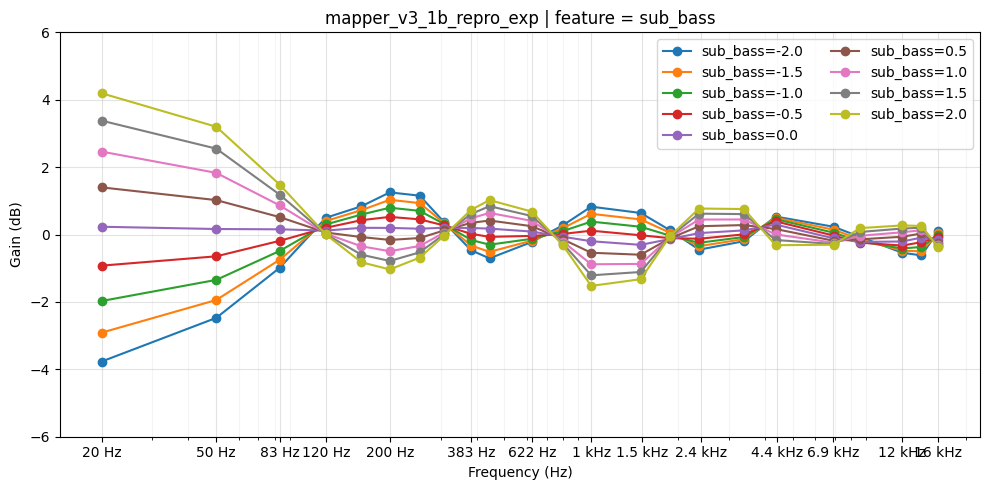

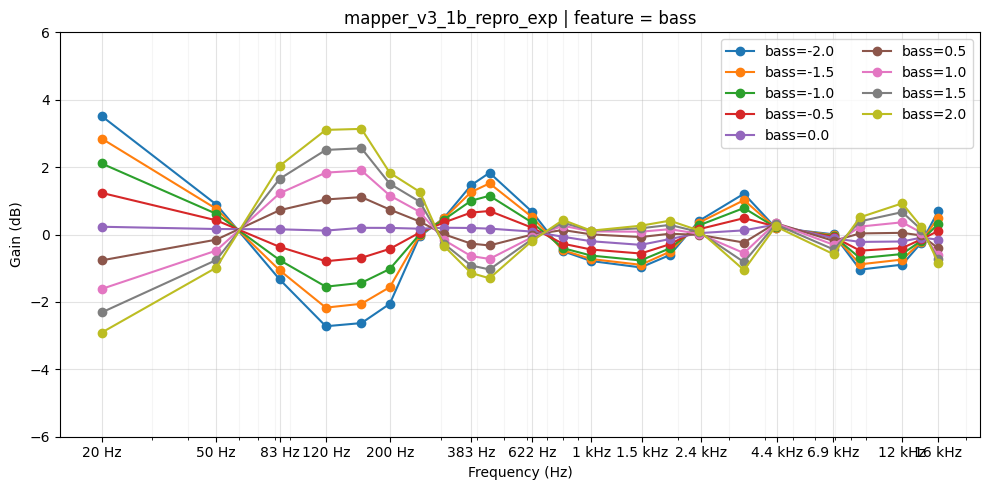

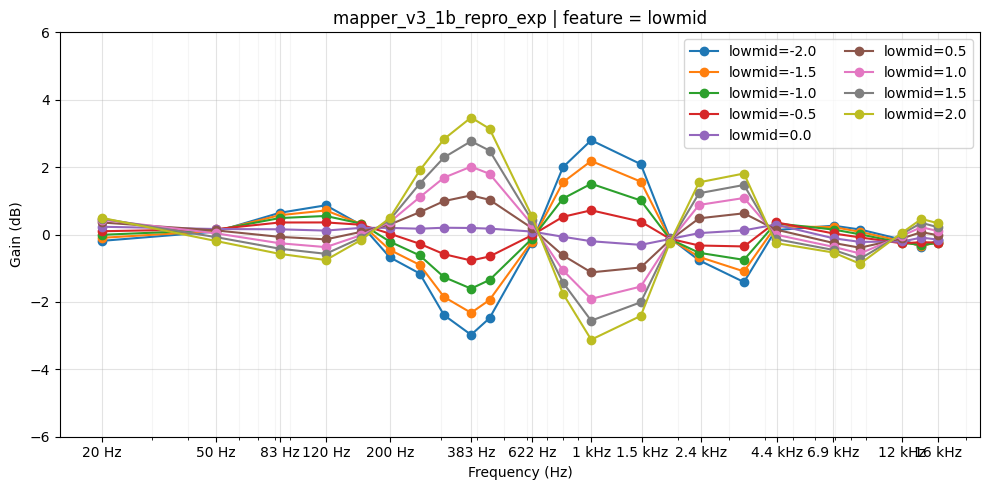

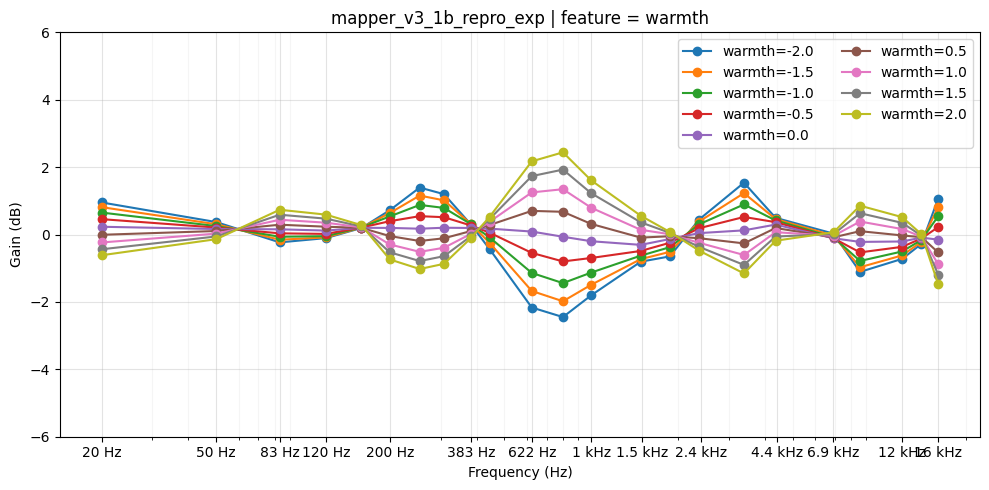

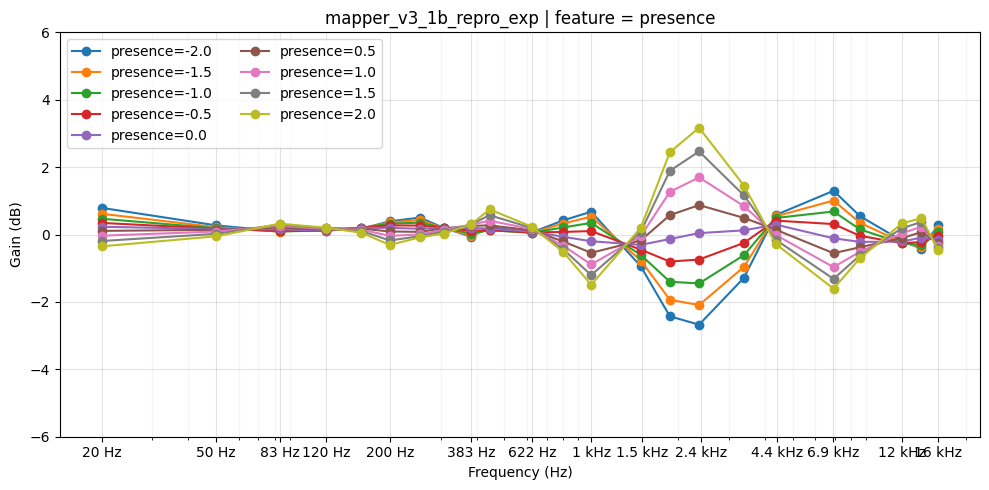

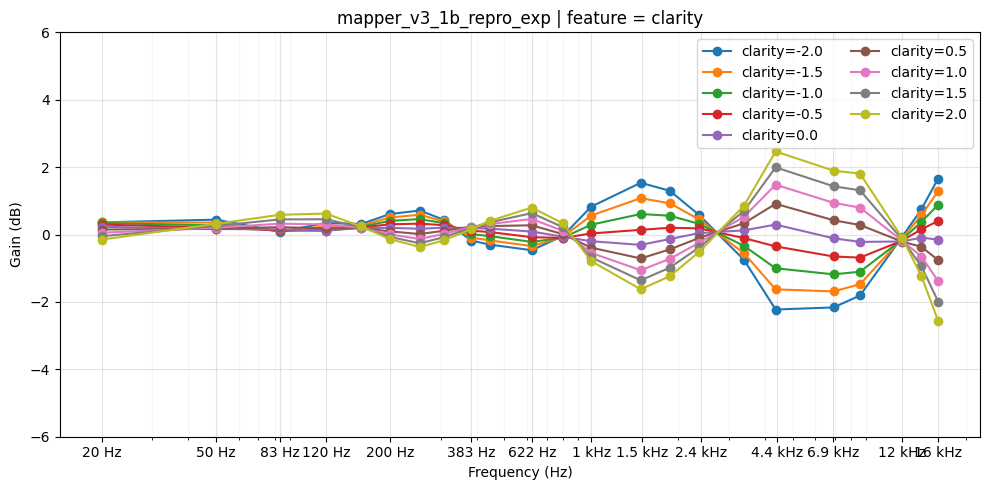

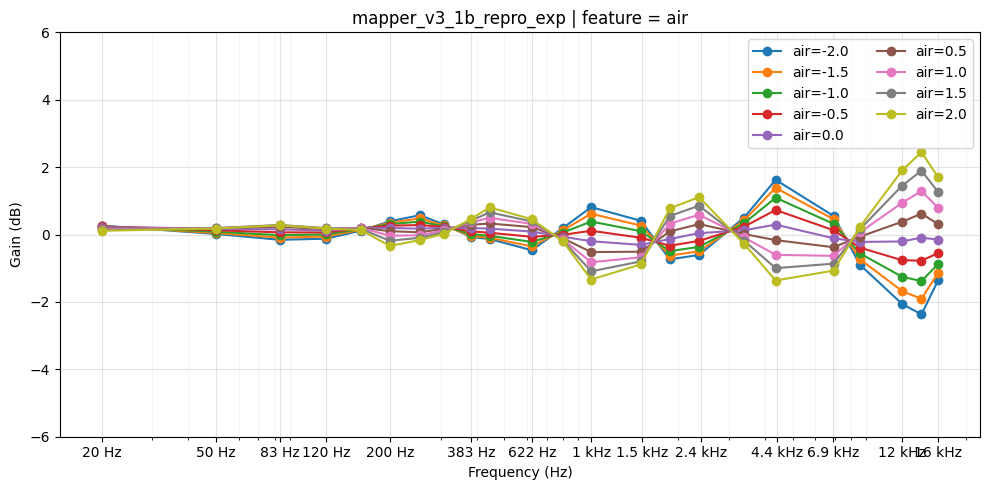

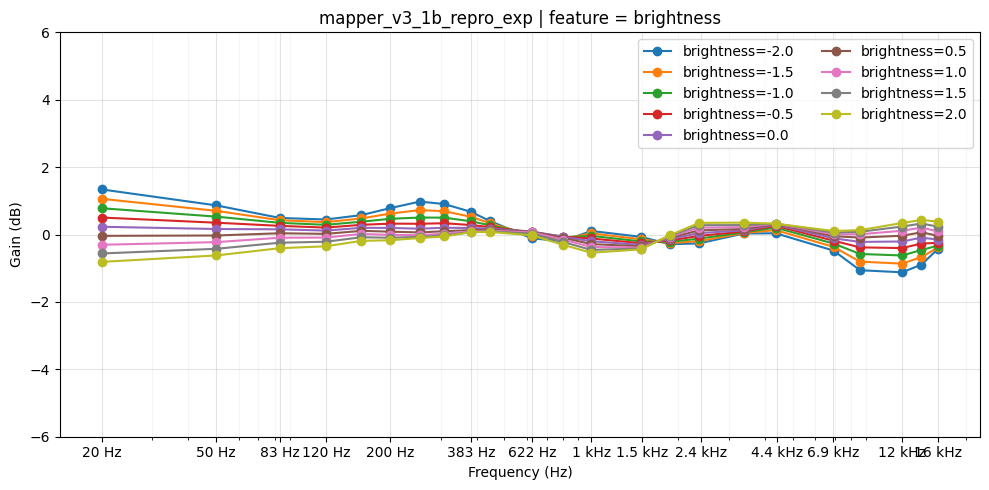

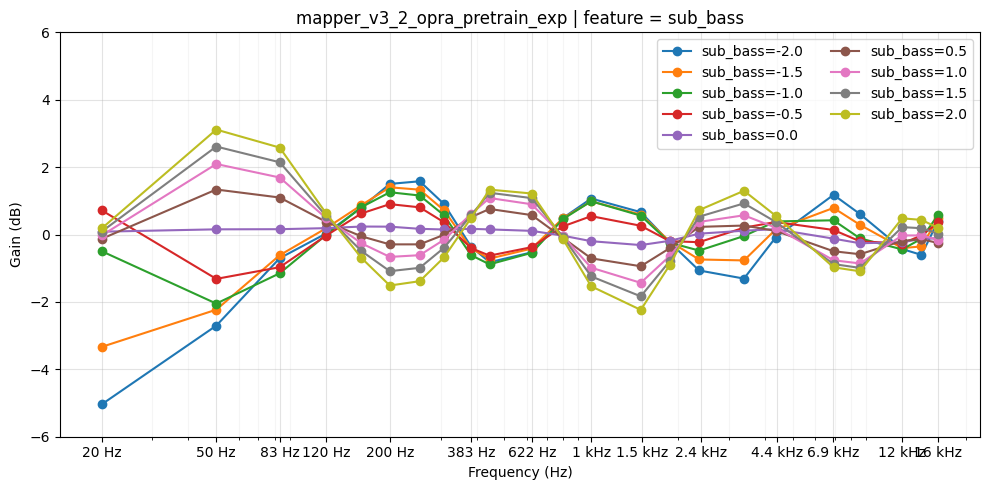

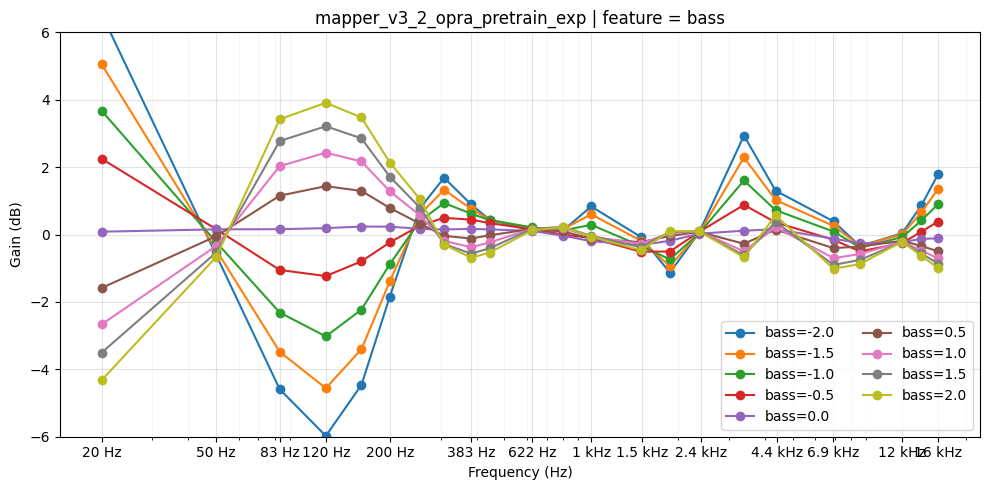

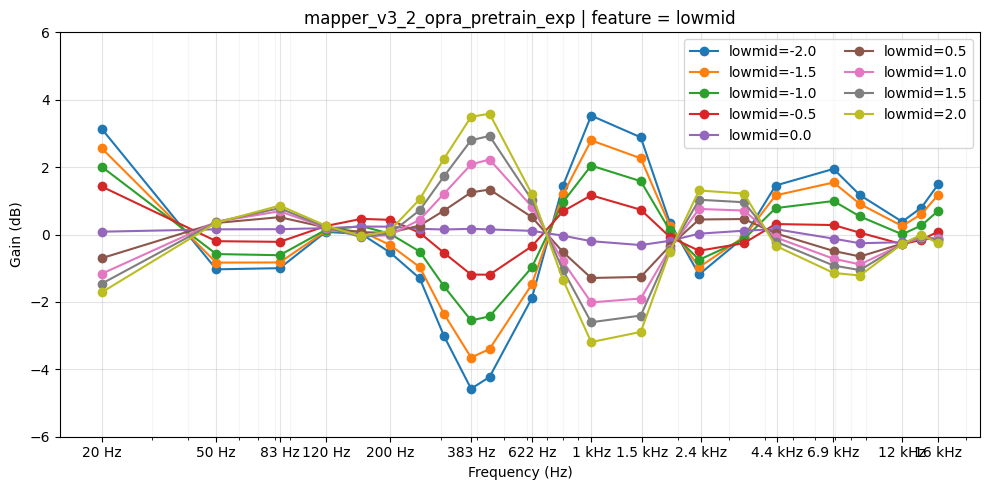

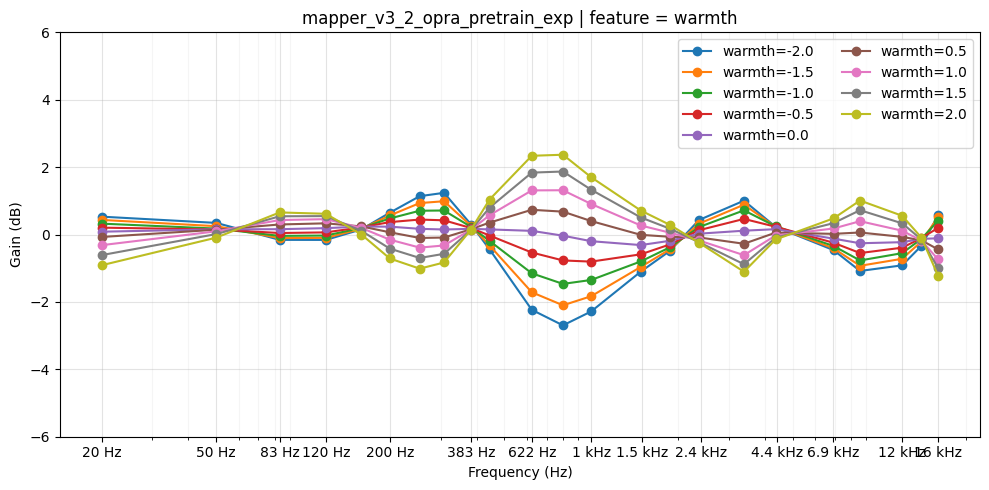

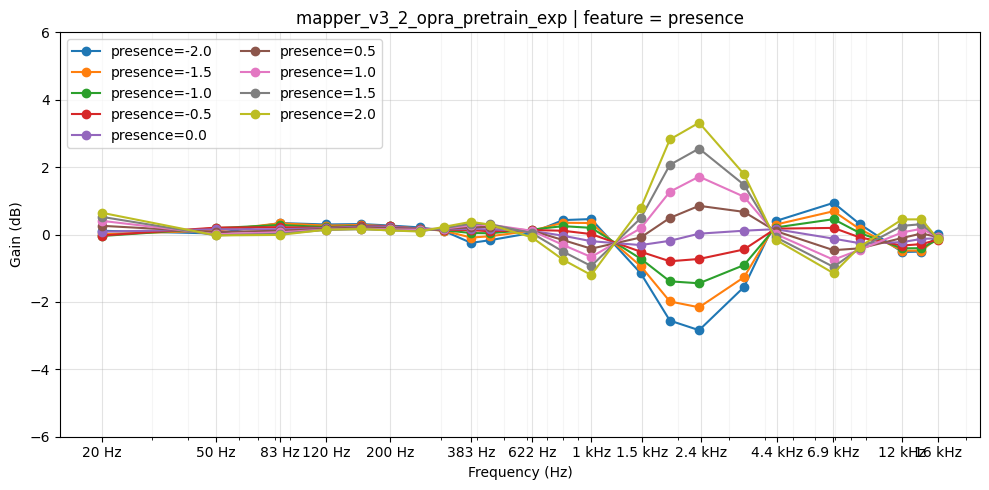

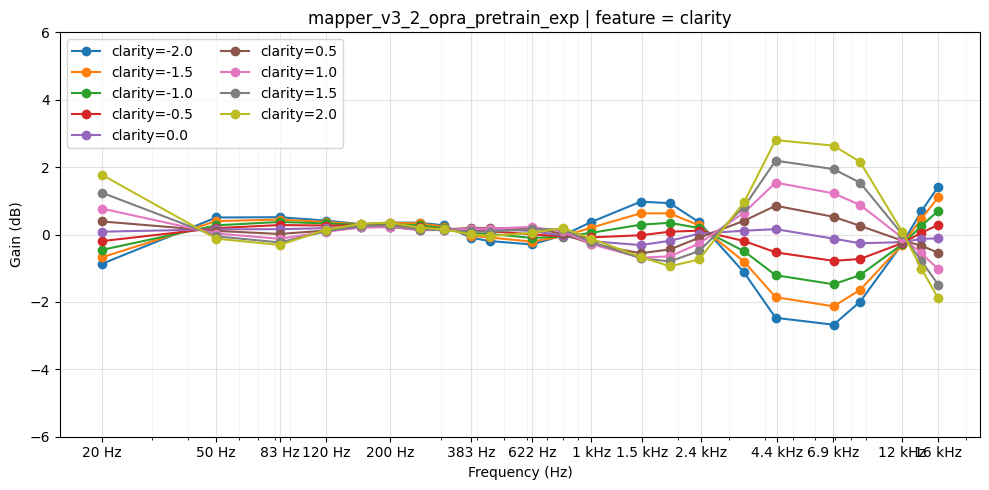

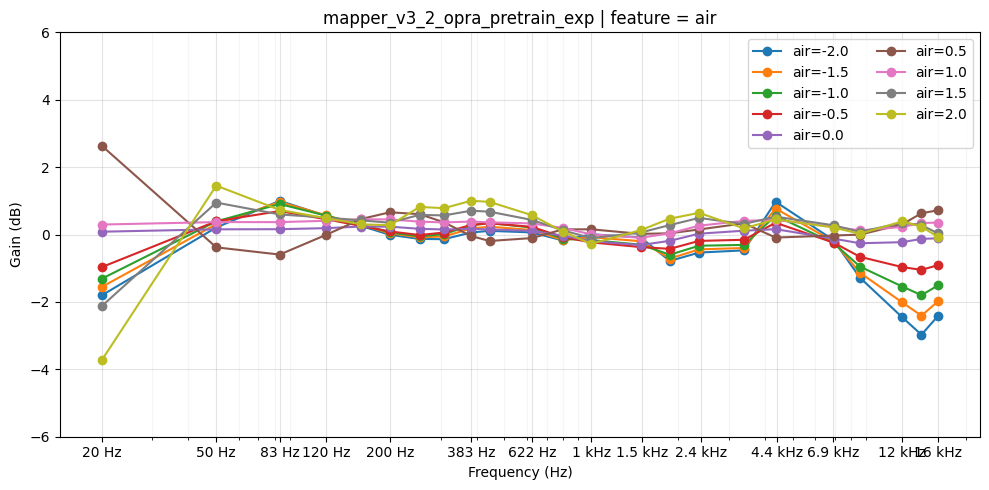

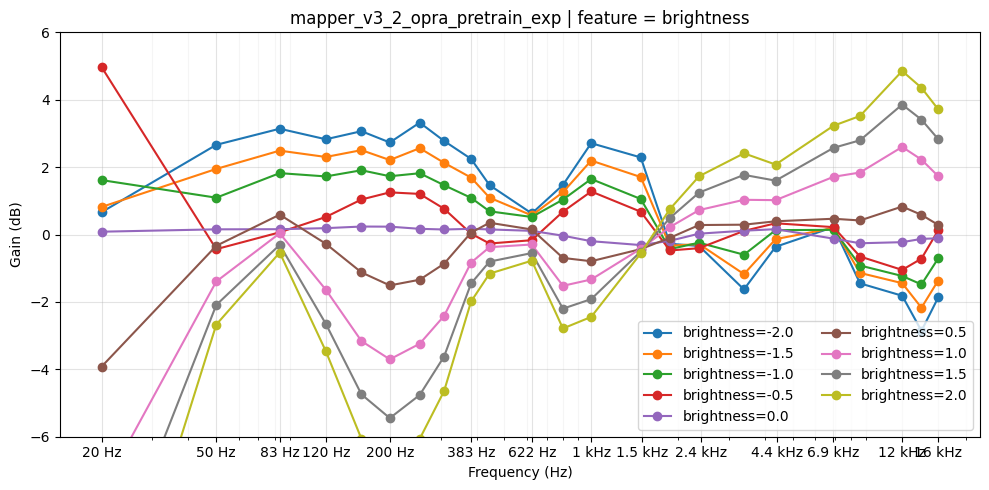

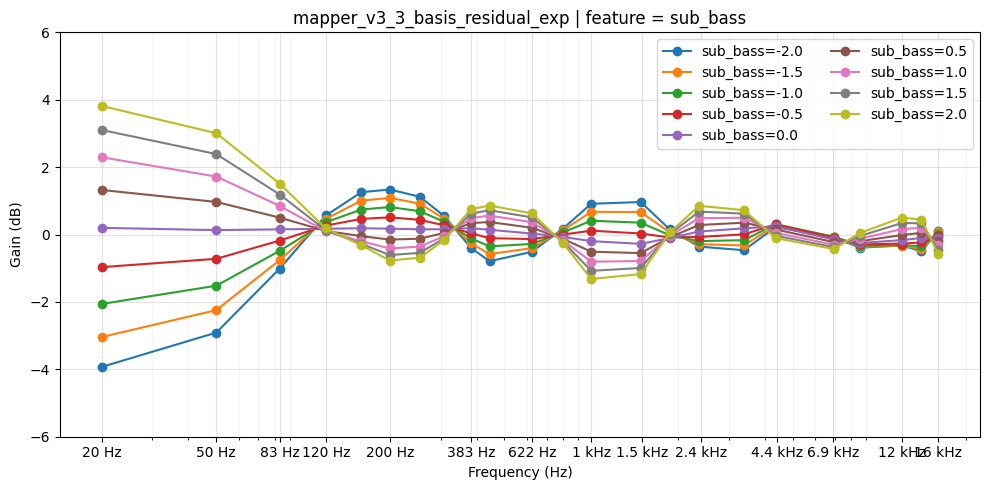

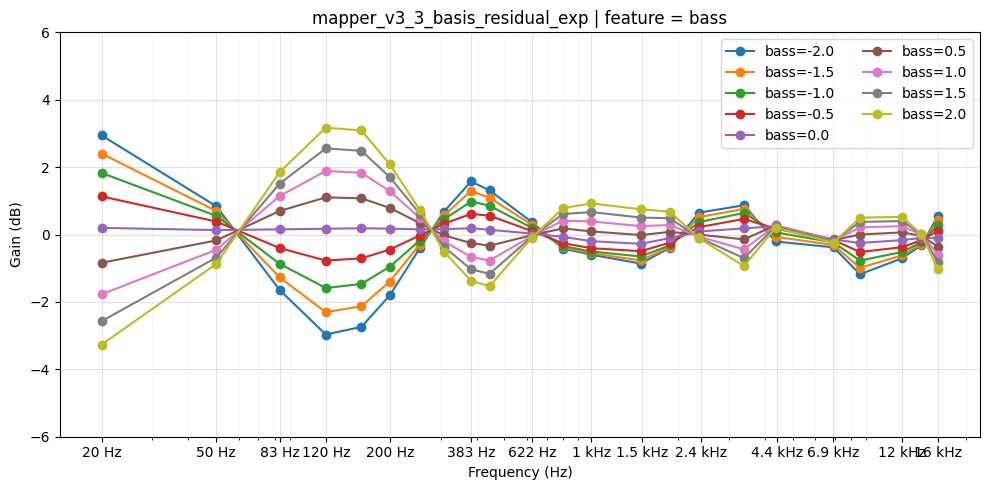

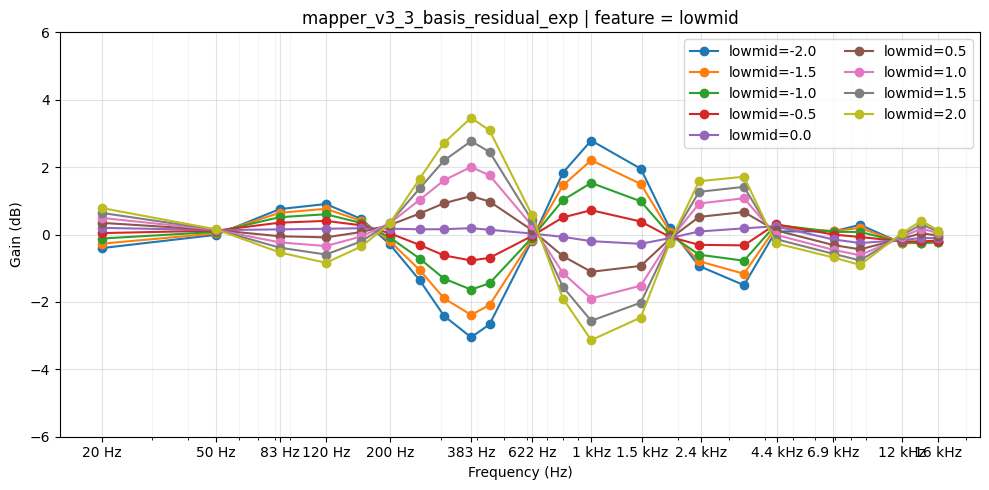

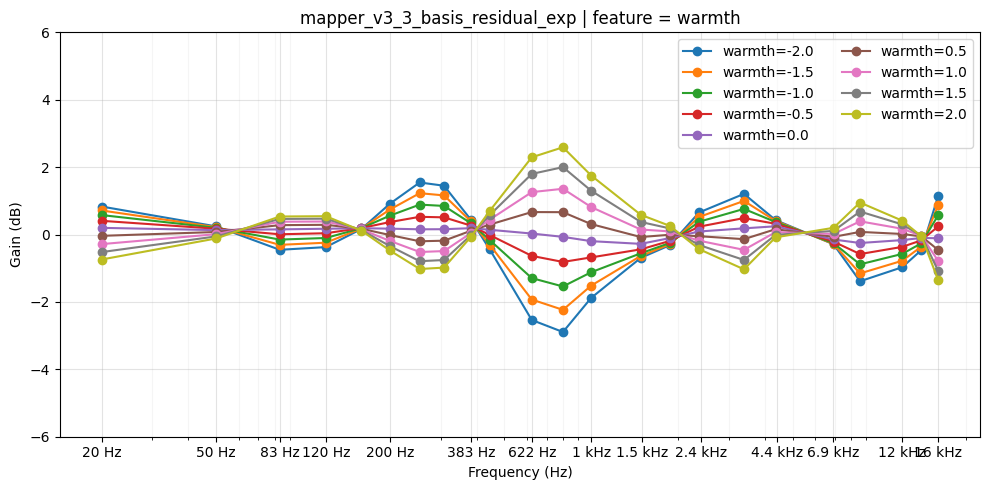

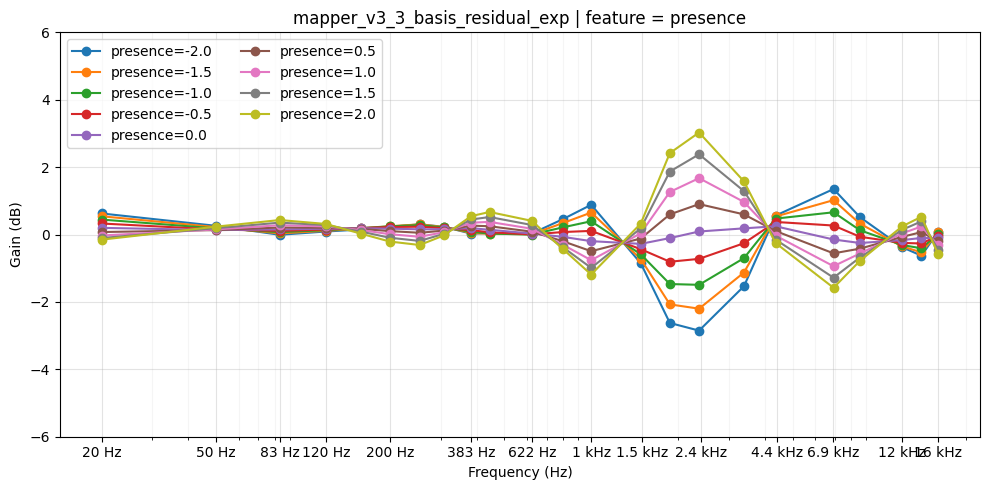

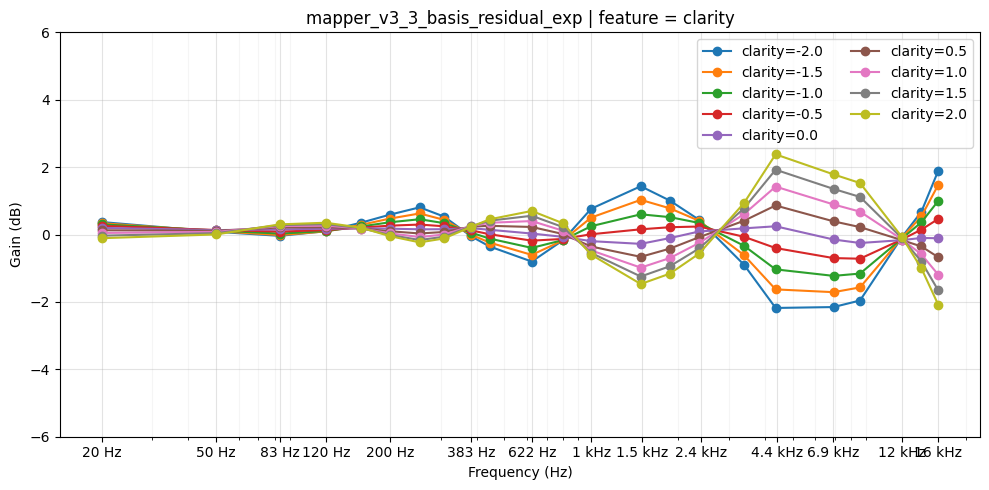

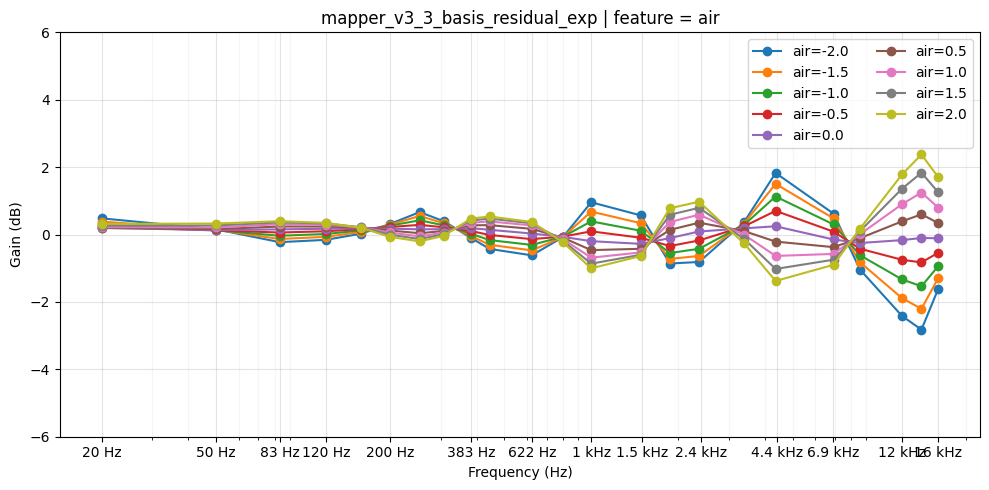

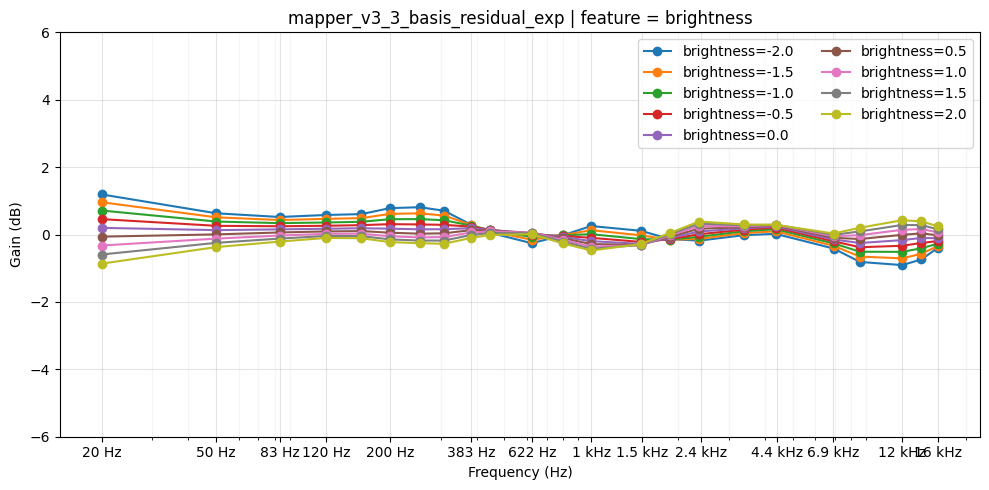

In [20]:
# ==== Final sweeps for each completed model ====

for model_name, exp in model_map.items():
    for feature_name in FEATURE_NAMES_8D:
        plot_axis_sweep(
            exp,
            freqs_23,
            feature_name,
            FEATURE_NAMES_8D,
            ylim=(-6, 6),
            title_prefix=model_name,
        )


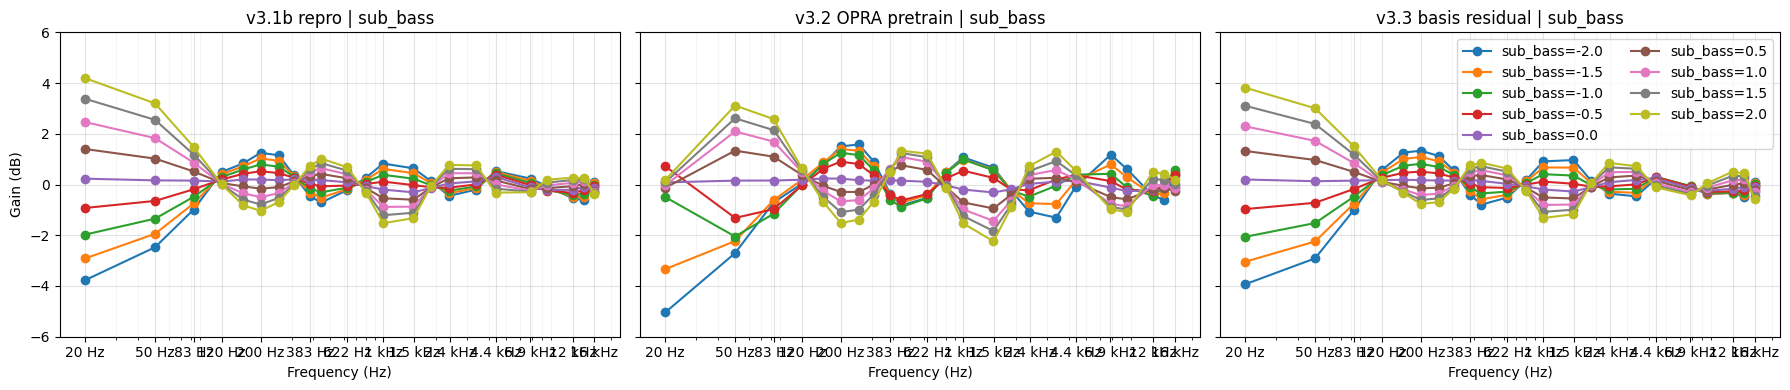

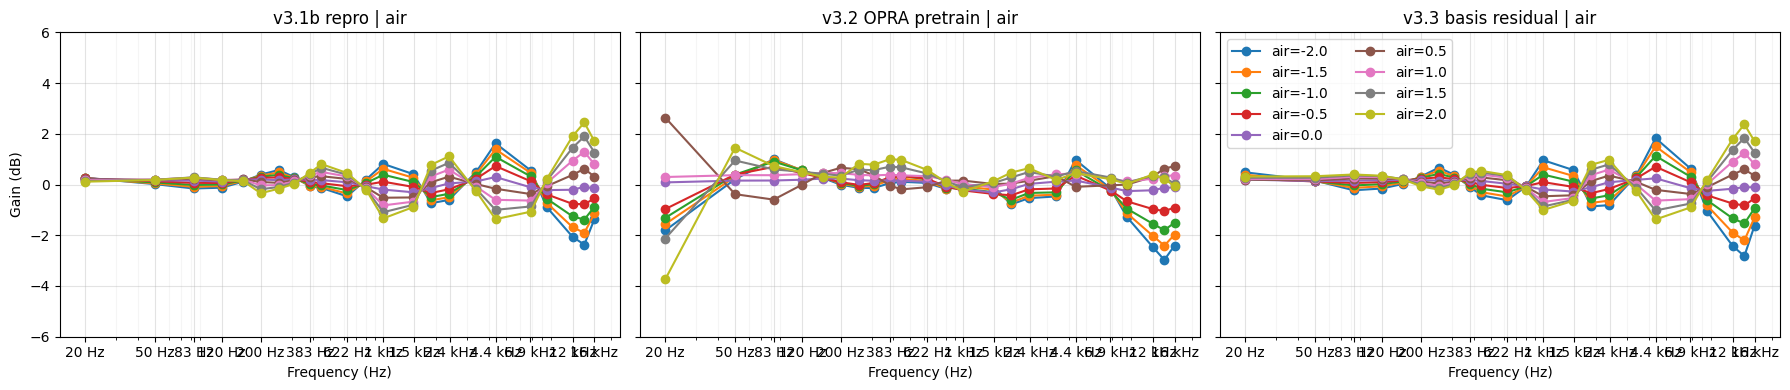

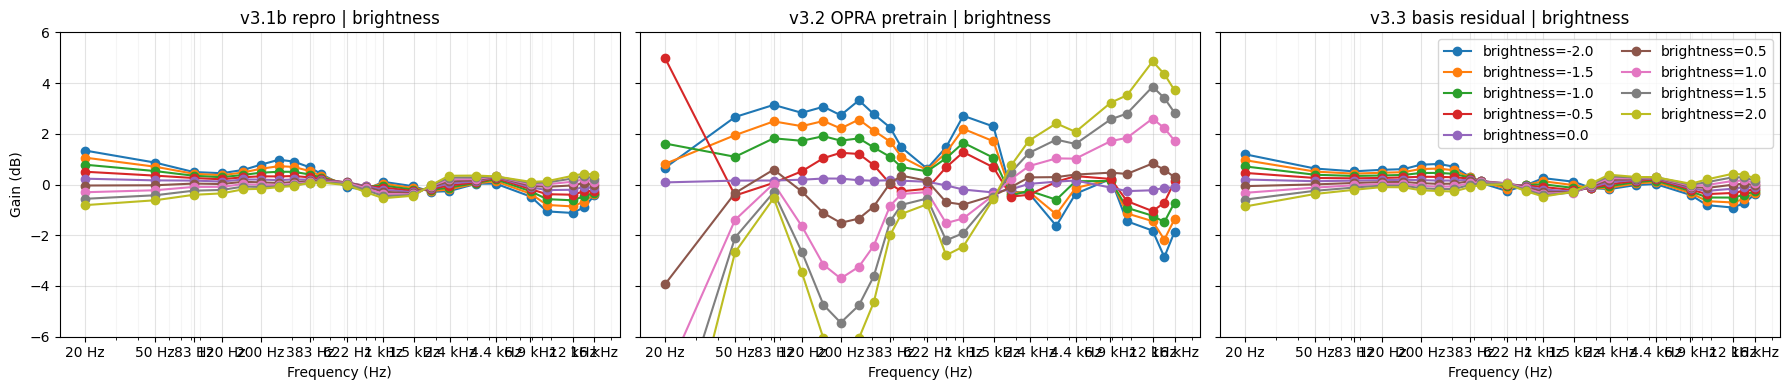

In [21]:
# ==== Side-by-side sweeps for edge controls ====

comparison_models = {
    "v3.1b repro": mapper_v3_1b_repro_exp,
    "v3.2 OPRA pretrain": mapper_v3_2_opra_pretrain_exp,
    "v3.3 basis residual": mapper_v3_3_basis_residual_exp,
}

for feature_name in ["sub_bass", "air", "brightness"]:
    plot_side_by_side_feature_sweeps(
        comparison_models,
        feature_name,
        FEATURE_NAMES_8D,
        freqs_23,
        ylim=(-6, 6),
    )


In [22]:
# ==== Final markdown conclusion ====

baseline_row = df_compare[df_compare["model"] == "mapper_v3_1b_repro_exp"].iloc[0]
opra_row = df_compare[df_compare["model"] == "mapper_v3_2_opra_pretrain_exp"].iloc[0]
residual_row = df_compare[df_compare["model"] == "mapper_v3_3_basis_residual_exp"].iloc[0]

alignment_map = {
    row["model"]: row["mean_basis_alignment"]
    for _, row in df_alignment_summary.iterrows()
}

sensitivity_map = {
    row["model"]: row
    for _, row in df_sensitivity_summary.iterrows()
}

edge_pivot = df_edge_controls.pivot_table(
    index="feature",
    columns="model",
    values=["target_response", "target_off_ratio", "sign_consistency", "max_abs_slope"],
)


def better_or_comparable(candidate_name, baseline_name="mapper_v3_1b_repro_exp"):
    candidate = df_compare[df_compare["model"] == candidate_name].iloc[0]
    base = df_compare[df_compare["model"] == baseline_name].iloc[0]
    mse_ok = candidate["test_mse"] <= base["test_mse"] + 0.002
    ratio_ok = sensitivity_map[candidate_name]["mean_target_off_ratio"] >= sensitivity_map[baseline_name]["mean_target_off_ratio"] * 0.95
    align_ok = alignment_map[candidate_name] >= alignment_map[baseline_name] * 0.95
    sign_ok = sensitivity_map[candidate_name]["mean_sign_consistency"] >= sensitivity_map[baseline_name]["mean_sign_consistency"] * 0.95
    brightness_ok = (
        df_edge_controls[
            (df_edge_controls["model"] == candidate_name)
            & (df_edge_controls["feature"] == "brightness")
        ]["target_response"].iloc[0]
        >=
        df_edge_controls[
            (df_edge_controls["model"] == baseline_name)
            & (df_edge_controls["feature"] == "brightness")
        ]["target_response"].iloc[0] * 0.9
    )
    return mse_ok and ratio_ok and align_ok and sign_ok and brightness_ok


selected_model = "mapper_v3_1b_repro_exp"
for candidate_name in ["mapper_v3_2_opra_pretrain_exp", "mapper_v3_3_basis_residual_exp"]:
    if better_or_comparable(candidate_name):
        if df_compare[df_compare["model"] == candidate_name]["test_mse"].iloc[0] < df_compare[df_compare["model"] == selected_model]["test_mse"].iloc[0]:
            selected_model = candidate_name


conclusion_md = f"""
## Final conclusion

1. **OPRA pretraining and SocialFX test MSE**  
   Baseline v3.1b repro test MSE = `{baseline_row['test_mse']:.5f}`.  
   v3.2 OPRA pretrain -> fine-tune test MSE = `{opra_row['test_mse']:.5f}`.  
   Improvement vs baseline = `{opra_row['test_mse'] - baseline_row['test_mse']:+.5f}`.

2. **OPRA edge controls: sub_bass / air / brightness**  
   Use `df_edge_controls` for the exact per-feature table. This is the deciding table for whether OPRA expanded useful low/high-end controllability without suppressing brightness.

3. **Controllability impact of OPRA**  
   Mean basis alignment: baseline = `{alignment_map['mapper_v3_1b_repro_exp']:.3f}`, OPRA = `{alignment_map['mapper_v3_2_opra_pretrain_exp']:.3f}`.  
   Mean target/off ratio: baseline = `{sensitivity_map['mapper_v3_1b_repro_exp']['mean_target_off_ratio']:.3f}`, OPRA = `{sensitivity_map['mapper_v3_2_opra_pretrain_exp']['mean_target_off_ratio']:.3f}`.

4. **BasisResidualMapper controllability**  
   v3.3 test MSE = `{residual_row['test_mse']:.5f}`.  
   Mean basis alignment = `{alignment_map['mapper_v3_3_basis_residual_exp']:.3f}`.  
   Mean target/off ratio = `{sensitivity_map['mapper_v3_3_basis_residual_exp']['mean_target_off_ratio']:.3f}`.

5. **Selected main mapper**  
   Current selected model by the notebook rule set: **`{selected_model}`**.

6. **Decision rule interpretation**  
   If neither v3.2 nor v3.3 beats the v3.1b baseline under the combined criteria, then `mapper_v3_1b_repro_exp` remains the main mapper. This notebook does not force a positive result if the new models do not improve the trade-off.
"""

display(Markdown(conclusion_md))



## Final conclusion

1. **OPRA pretraining and SocialFX test MSE**  
   Baseline v3.1b repro test MSE = `0.03398`.  
   v3.2 OPRA pretrain -> fine-tune test MSE = `0.03431`.  
   Improvement vs baseline = `+0.00033`.

2. **OPRA edge controls: sub_bass / air / brightness**  
   Use `df_edge_controls` for the exact per-feature table. This is the deciding table for whether OPRA expanded useful low/high-end controllability without suppressing brightness.

3. **Controllability impact of OPRA**  
   Mean basis alignment: baseline = `0.695`, OPRA = `0.702`.  
   Mean target/off ratio: baseline = `3.711`, OPRA = `4.088`.

4. **BasisResidualMapper controllability**  
   v3.3 test MSE = `0.03365`.  
   Mean basis alignment = `0.692`.  
   Mean target/off ratio = `3.680`.

5. **Selected main mapper**  
   Current selected model by the notebook rule set: **`mapper_v3_1b_repro_exp`**.

6. **Decision rule interpretation**  
   If neither v3.2 nor v3.3 beats the v3.1b baseline under the combined criteria, then `mapper_v3_1b_repro_exp` remains the main mapper. This notebook does not force a positive result if the new models do not improve the trade-off.
